# 12. Macro Fiancial Conditions Index

In [ ]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.stats import spearmanr
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.portfolio import make_rebalance_dates, prices_to_returns
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_metrics_table, build_trade_table, calc_drawdown
from quantfinlab.risk import drawdown_series
from quantfinlab.fixed_income.term_models import estimate_pca_curve
from quantfinlab.plotting.portfolio import plot_strategy_nav, plot_strategy_drawdowns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})


In [2]:
repo_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = repo_dir / "data"
factor_path = data_dir / "us_macro_factors.csv"
etf_path = data_dir / "ETF_data.csv"
nfci_path = data_dir / "nfci-data-series.csv"
rf_annual = 0.04
rf_monthly = (1.0 + rf_annual) ** (1.0 / 12.0) - 1.0


In [3]:
macro_factors = pd.read_csv(factor_path, parse_dates=["date"]).set_index("date")
macro_factors = macro_factors.sort_index()
macro_factors.index = macro_factors.index.to_period("M").to_timestamp("M")
macro_factors = macro_factors.groupby(macro_factors.index).last()
macro_factors = macro_factors.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
minimum_visible_date = macro_factors.index.min()
factor_availability = pd.DataFrame({
    "first_date": macro_factors.apply(pd.Series.first_valid_index),
    "last_date": macro_factors.apply(pd.Series.last_valid_index),
    "observations": macro_factors.notna().sum(),
    "available_share": macro_factors.notna().mean(),
}).sort_values(["first_date", "observations"])
display(pd.DataFrame({"start": [macro_factors.index.min()], "end": [macro_factors.index.max()], "rows": [len(macro_factors)], "factors": [macro_factors.shape[1]]}))
display(factor_availability.head(20))


,start,end,rows,factors
0,1990-01-31,2026-01-31,433,57


,first_date,last_date,observations,available_share
exp_exports_goods_services,1990-01-31,2014-03-31,291,0.672055
imp_imports_goods_services,1990-01-31,2014-03-31,291,0.672055
cnci_oecd_consumer_confidence,1990-01-31,2024-03-31,411,0.949192
bsi_oecd_business_confidence,1990-01-31,2024-03-31,411,0.949192
cpi_all_items,1990-01-31,2026-01-31,433,1.000000
cpc_core_cpi,1990-01-31,2026-01-31,433,1.000000
cpc_pce_price,1990-01-31,2026-01-31,433,1.000000
cpc_core_pce,1990-01-31,2026-01-31,433,1.000000
ppi_all_commodities,1990-01-31,2026-01-31,433,1.000000
ppi_final_demand,1990-01-31,2026-01-31,433,1.000000


In [4]:
def expanding_zscore(series, min_obs=60, clip=5.0):
    series = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    mean = series.expanding(min_periods=min_obs).mean()
    std = series.expanding(min_periods=min_obs).std(ddof=1).replace(0.0, np.nan)
    z = (series - mean) / std
    return z.clip(-clip, clip) if clip is not None else z

def prefix_cols(data, prefixes):
    prefixes = tuple(prefixes)
    return [col for col in data.columns if col.startswith(prefixes)]

def mean_z(data, columns, min_obs=60, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    return sign * z.mean(axis=1, skipna=True)

def change_z(data, columns, periods=3, min_obs=60, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].diff(periods).apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    return sign * z.mean(axis=1, skipna=True)

def stress_share(data, columns, min_obs=60, threshold=0.5, sign=1.0):
    if len(columns) == 0:
        return pd.Series(np.nan, index=data.index)
    z = data[columns].apply(lambda s: expanding_zscore(s, min_obs=min_obs))
    events = sign * z > threshold
    share = events.where(z.notna()).mean(axis=1, skipna=True)
    return expanding_zscore(share, min_obs=min_obs)

def plot_signal_group(data, title, ncols=2):
    cols = list(data.columns)
    nrows = math.ceil(len(cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 2.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        series = data[col].loc[data.index >= minimum_visible_date].dropna()
        series.plot(ax=axes[i], lw=1.2, color=colors[i % len(colors)])
        axes[i].axhline(0.0, color="black", lw=0.7, alpha=0.4)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xlabel("")
        axes[i].grid(True, alpha=0.25)
    for ax in axes[len(cols):]:
        ax.set_axis_off()
    fig.suptitle(title, y=1.02, fontsize=11)
    plt.tight_layout()
    plt.show()
    return fig, axes


In [5]:
min_obs = 60
inflation_cols = prefix_cols(macro_factors, ("cpi", "cpc", "ppi", "ipp", "rmp", "cpu"))
policy_cols = prefix_cols(macro_factors, ("inrt", "fdrh", "fdph", "gvbg"))
growth_cols = prefix_cols(macro_factors, ("gdp", "inp", "rsa", "rsl", "pmmn", "pmsr", "pmcp", "ism", "isnf", "clin", "ldii", "ivp"))
labor_unemployment_cols = prefix_cols(macro_factors, ("unrt",))
labor_claims_cols = prefix_cols(macro_factors, ("injc", "ctcl"))
labor_jobs_cols = prefix_cols(macro_factors, ("nfp", "adpe", "emch", "emci", "whs", "avwh"))
housing_cols = prefix_cols(macro_factors, ("hbp", "hsp", "hos", "hoe", "hon", "hop", "nhp", "nahb", "psi", "s20"))
external_demand_cols = prefix_cols(macro_factors, ("exp", "imp"))
external_balance_cols = prefix_cols(macro_factors, ("trbn", "crab"))
survey_cols = prefix_cols(macro_factors, ("cnci", "cncr", "cnrm", "cnry", "umcc", "bsi", "zwi", "zwe", "sntx", "cct", "cit"))


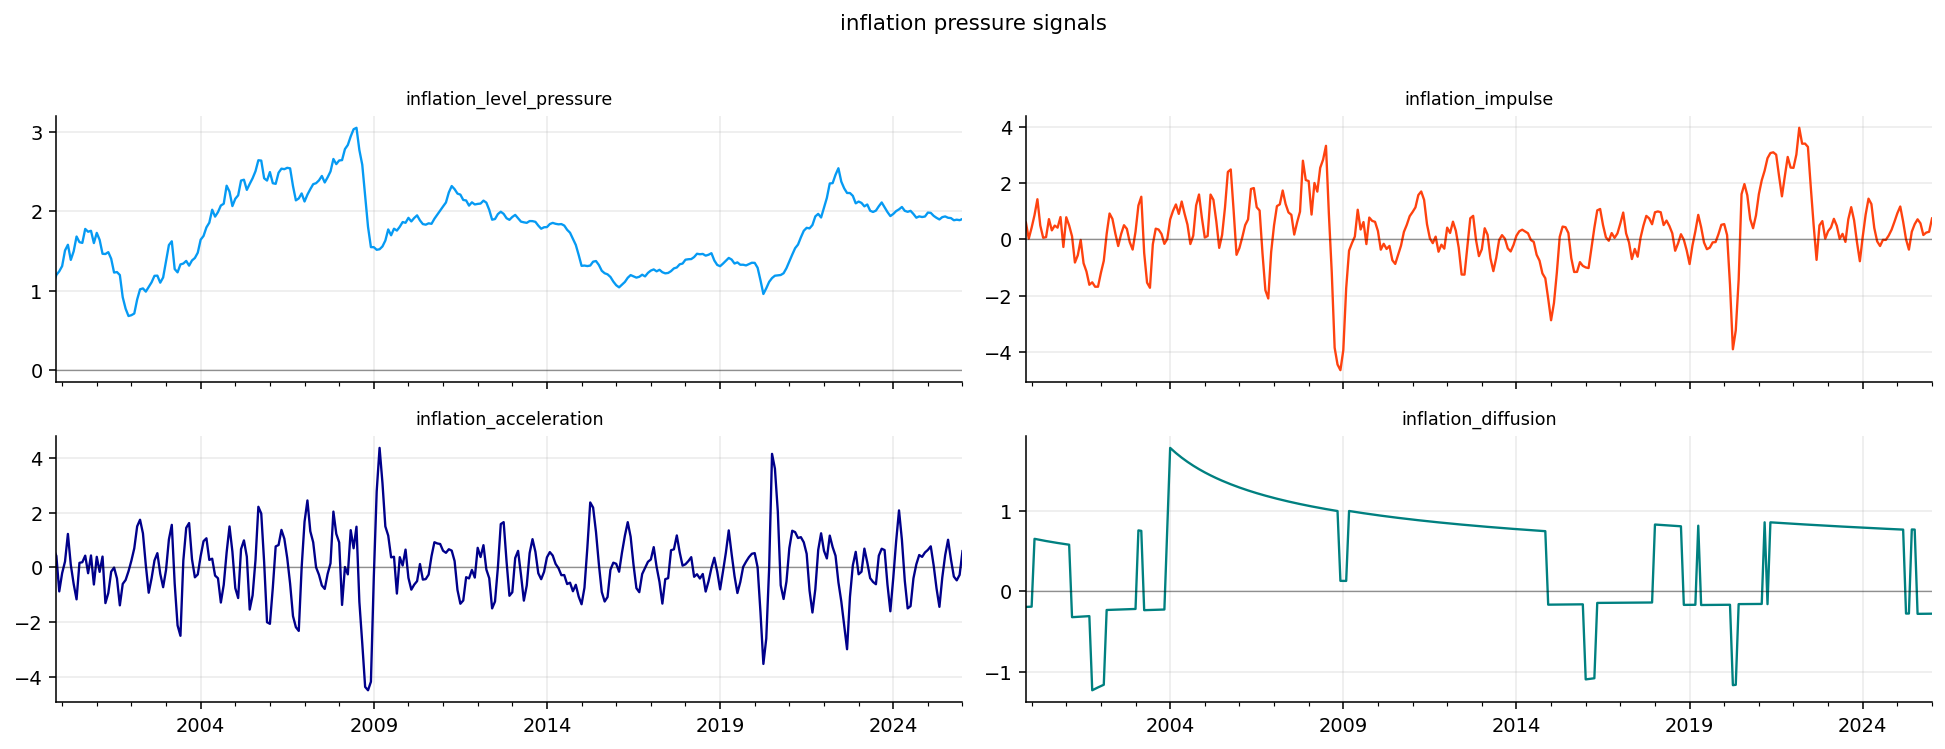

,inflation_level_pressure,inflation_impulse,inflation_acceleration,inflation_diffusion
date,,,,
2025-09-30,1.913833,0.572598,0.283507,-0.280186
2025-10-31,1.886823,0.156250,-0.341571,-0.279780
2025-11-30,1.894163,0.242142,-0.480572,-0.279375
2025-12-31,1.887851,0.271403,-0.280847,-0.278972
2026-01-31,1.903459,0.747146,0.588010,-0.278571


In [6]:
inflation_signals = pd.DataFrame(index=macro_factors.index)
inflation_signals["inflation_level_pressure"] = mean_z(macro_factors, inflation_cols, min_obs=min_obs)
inflation_signals["inflation_impulse"] = change_z(macro_factors, inflation_cols, periods=3, min_obs=min_obs)
inflation_accel = macro_factors[inflation_cols].diff(3).diff(3)
inflation_signals["inflation_acceleration"] = inflation_accel.apply(lambda s: expanding_zscore(s, min_obs=min_obs)).mean(axis=1, skipna=True)
inflation_signals["inflation_diffusion"] = stress_share(macro_factors, inflation_cols, min_obs=min_obs, threshold=0.5)
plot_signal_group(inflation_signals, "inflation pressure signals")
display(inflation_signals.tail())


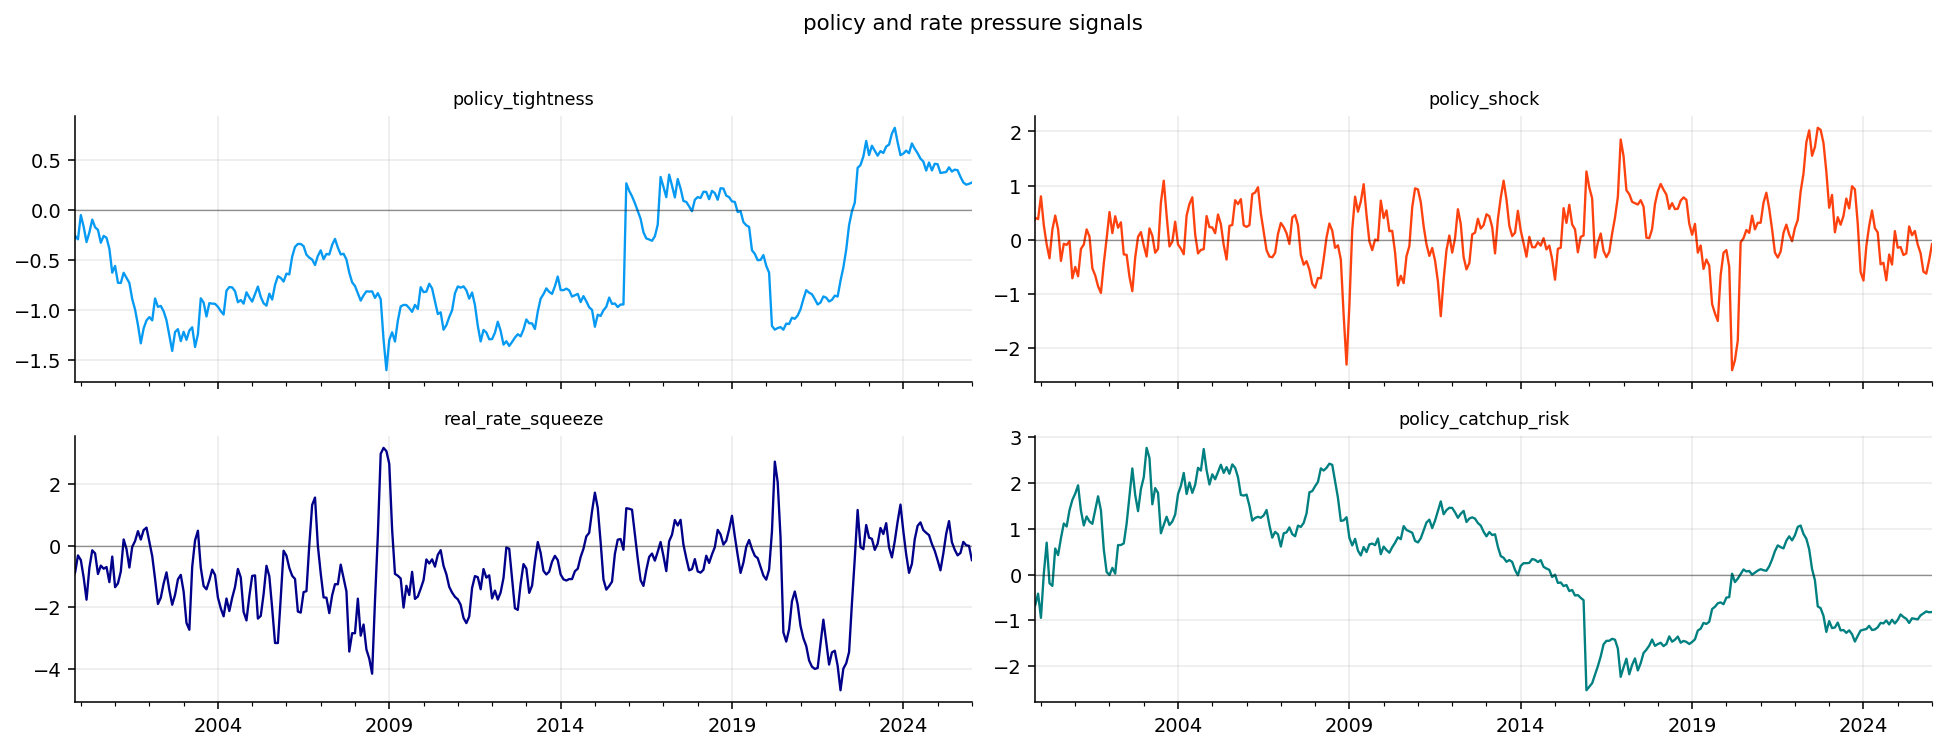

,policy_tightness,policy_shock,real_rate_squeeze,policy_catchup_risk
date,,,,
2025-09-30,0.333683,-0.252234,-0.238916,-0.889728
2025-10-31,0.277807,-0.593257,0.121558,-0.847508
2025-11-30,0.255488,-0.629775,0.013346,-0.804348
2025-12-31,0.263783,-0.377883,-0.007620,-0.822879
2026-01-31,0.276304,-0.084204,-0.470842,-0.816744


In [7]:
policy_signals = pd.DataFrame(index=macro_factors.index)
policy_signals["policy_tightness"] = mean_z(macro_factors, policy_cols, min_obs=min_obs)
policy_signals["policy_shock"] = change_z(macro_factors, policy_cols, periods=3, min_obs=min_obs)
policy_signals["real_rate_squeeze"] = policy_signals["policy_tightness"] - inflation_signals["inflation_impulse"]
policy_gap = inflation_signals["inflation_level_pressure"] - policy_signals["policy_tightness"]
policy_signals["policy_catchup_risk"] = expanding_zscore(policy_gap.clip(lower=0.0), min_obs=min_obs)
plot_signal_group(policy_signals, "policy and rate pressure signals")
display(policy_signals.tail())


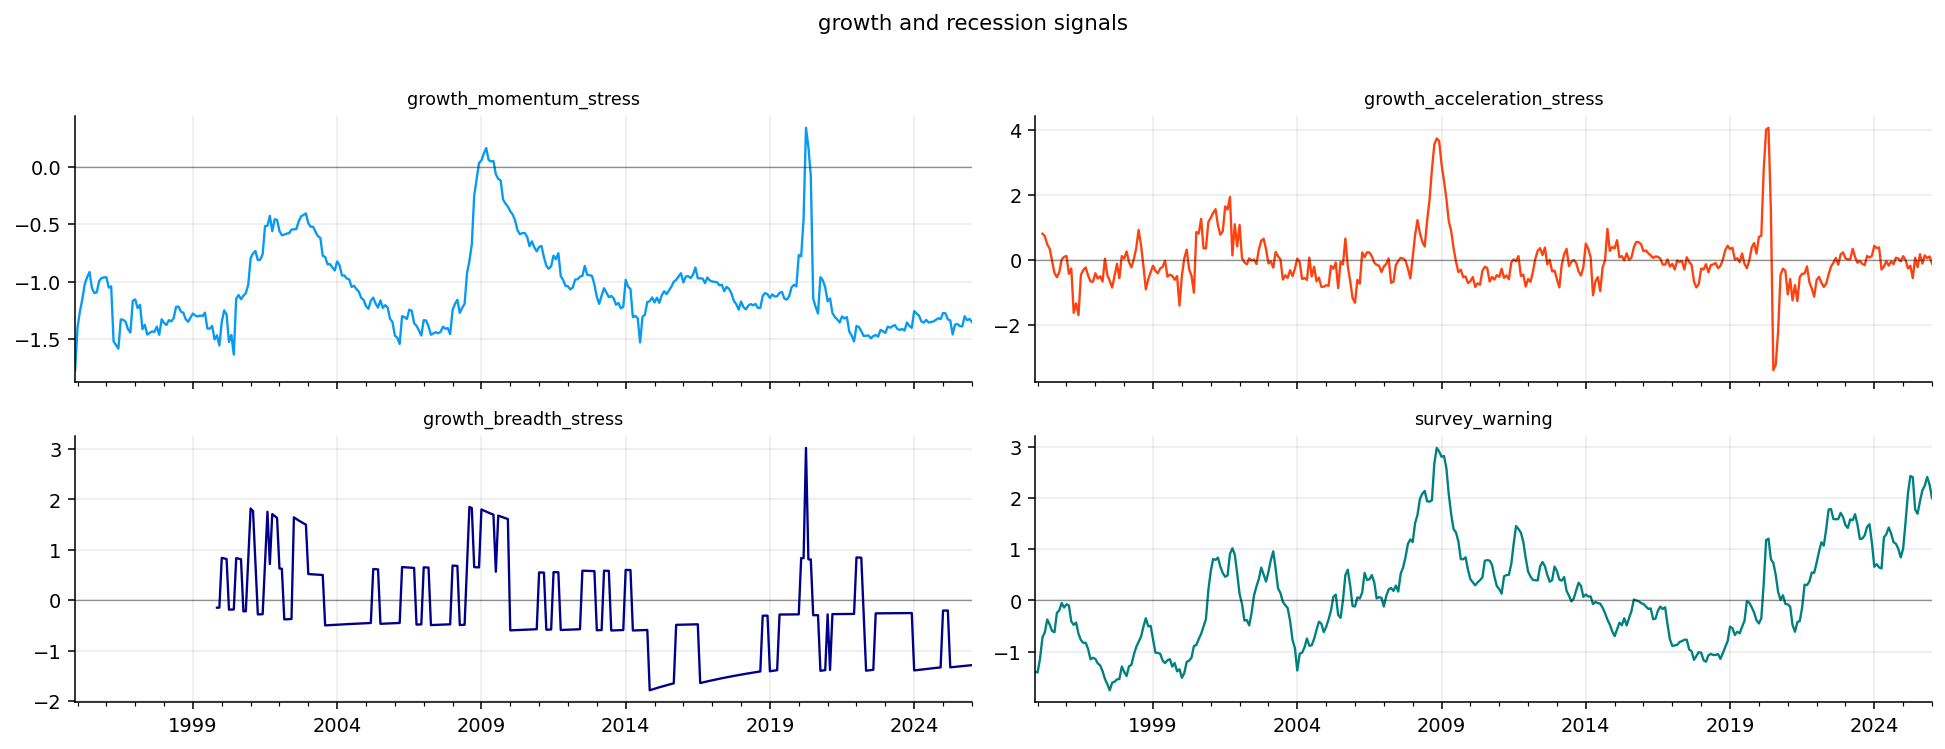

,growth_momentum_stress,growth_acceleration_stress,growth_breadth_stress,survey_warning
date,,,,
2025-09-30,-1.389831,-0.101126,-1.302400,2.152217
2025-10-31,-1.301853,0.151222,-1.297677,2.245408
2025-11-30,-1.336166,0.067573,-1.293005,2.414330
2025-12-31,-1.324761,0.118781,-1.288383,2.261299
2026-01-31,-1.351111,-0.100199,-1.283811,1.998803


In [8]:
growth_signals = pd.DataFrame(index=macro_factors.index)
growth_signals["growth_momentum_stress"] = mean_z(macro_factors, growth_cols, min_obs=min_obs, sign=-1.0)
growth_signals["growth_acceleration_stress"] = change_z(macro_factors, growth_cols, periods=3, min_obs=min_obs, sign=-1.0)
growth_signals["growth_breadth_stress"] = stress_share(macro_factors, growth_cols, min_obs=min_obs, threshold=0.5, sign=-1.0)
growth_signals["survey_warning"] = mean_z(macro_factors, survey_cols, min_obs=min_obs, sign=-1.0)
plot_signal_group(growth_signals, "growth and recession signals")
display(growth_signals.tail())


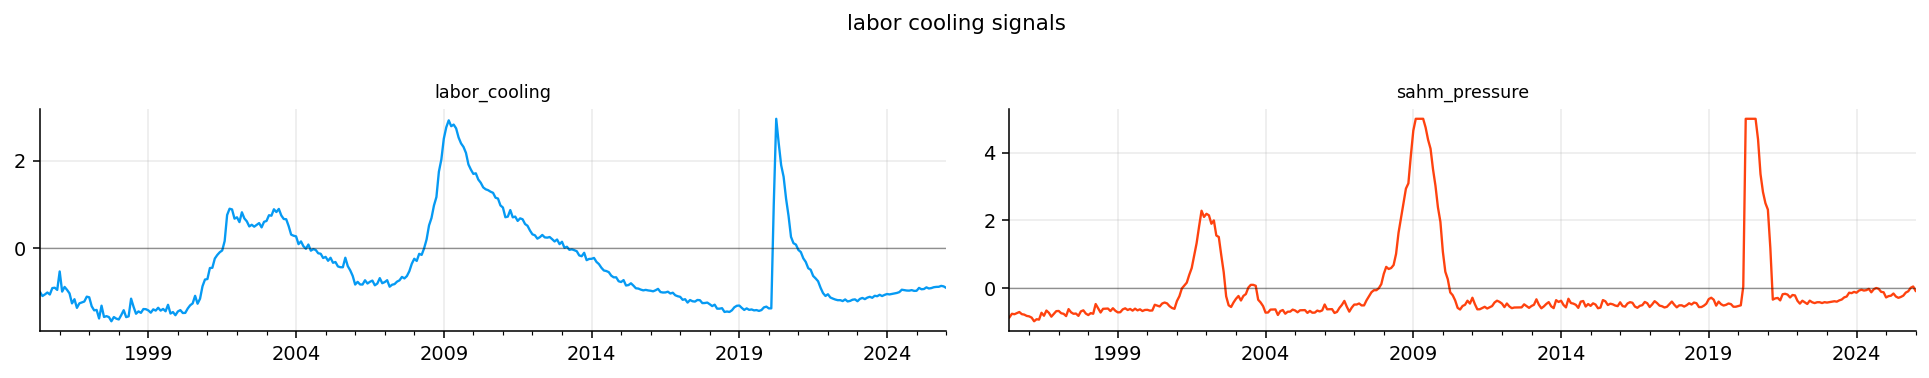

,labor_cooling,sahm_pressure
date,,
2025-09-30,-0.896948,-0.132507
2025-10-31,-0.894983,-0.093826
2025-11-30,-0.873793,0.009136
2025-12-31,-0.885415,0.047740
2026-01-31,-0.918880,-0.081183


In [9]:
labor_signals = pd.DataFrame(index=macro_factors.index)
labor_parts = pd.concat([
    mean_z(macro_factors, labor_unemployment_cols, min_obs=min_obs),
    mean_z(macro_factors, labor_claims_cols, min_obs=min_obs),
    mean_z(macro_factors, labor_jobs_cols, min_obs=min_obs, sign=-1.0),
], axis=1)
labor_signals["labor_cooling"] = labor_parts.mean(axis=1, skipna=True)
unemployment = macro_factors[labor_unemployment_cols].mean(axis=1, skipna=True)
sahm_gap = unemployment.rolling(3, min_periods=3).mean() - unemployment.rolling(12, min_periods=6).min()
labor_signals["sahm_pressure"] = expanding_zscore(sahm_gap, min_obs=min_obs)
plot_signal_group(labor_signals, "labor cooling signals")
display(labor_signals.tail())


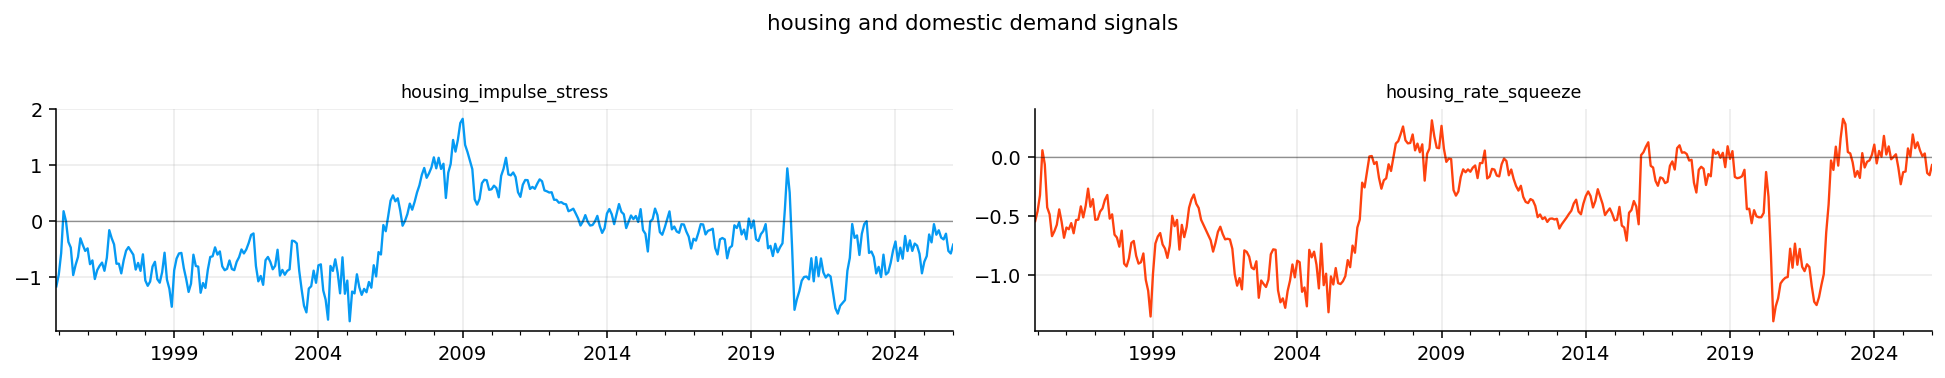

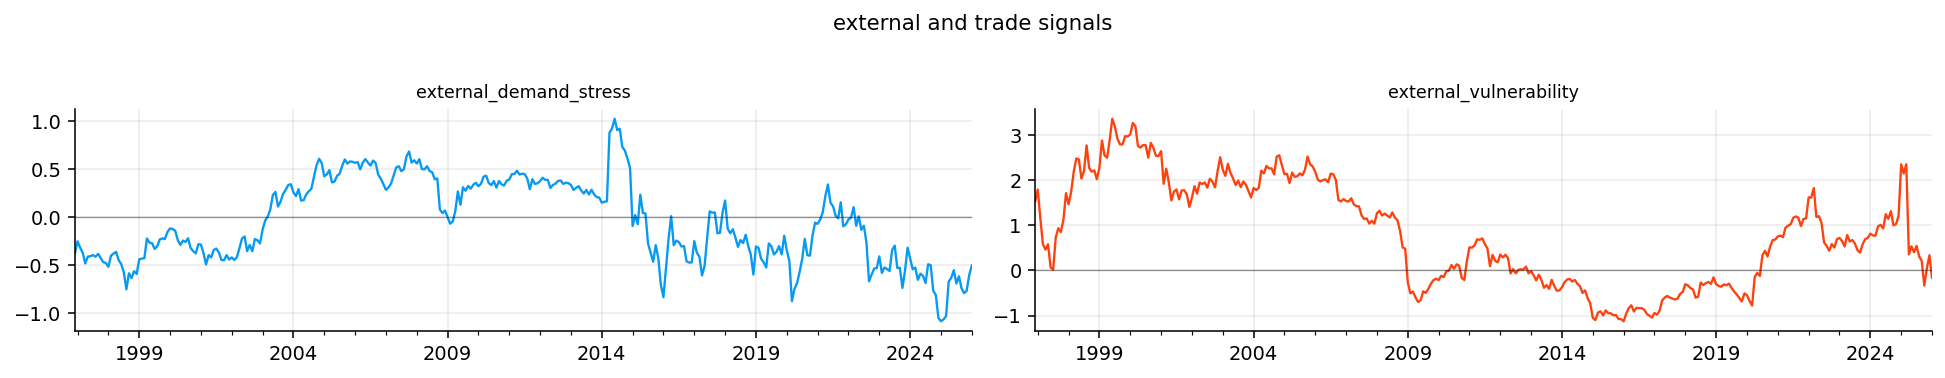

,housing_impulse_stress,housing_rate_squeeze,external_demand_stress,external_vulnerability
date,,,,
2025-09-30,-0.322739,0.005472,-0.740800,0.211200
2025-10-31,-0.220780,0.028514,-0.791354,-0.333764
2025-11-30,-0.527817,-0.136164,-0.767349,0.048908
2025-12-31,-0.573187,-0.154702,-0.601934,0.335830
2026-01-31,-0.414740,-0.069218,-0.503834,-0.163668


In [10]:
housing_external_signals = pd.DataFrame(index=macro_factors.index)
housing_level = mean_z(macro_factors, housing_cols, min_obs=min_obs, sign=-1.0)
housing_impulse = change_z(macro_factors, housing_cols, periods=3, min_obs=min_obs, sign=-1.0)
housing_external_signals["housing_impulse_stress"] = pd.concat([housing_level, housing_impulse], axis=1).mean(axis=1, skipna=True)
housing_external_signals["housing_rate_squeeze"] = pd.concat([housing_external_signals["housing_impulse_stress"], policy_signals["policy_tightness"]], axis=1).mean(axis=1, skipna=True)
housing_external_signals["external_demand_stress"] = mean_z(macro_factors, external_demand_cols, min_obs=min_obs, sign=-1.0)
housing_external_signals["external_vulnerability"] = mean_z(macro_factors, external_balance_cols, min_obs=min_obs, sign=-1.0)
plot_signal_group(housing_external_signals[["housing_impulse_stress", "housing_rate_squeeze"]], "housing and domestic demand signals")
plot_signal_group(housing_external_signals[["external_demand_stress", "external_vulnerability"]], "external and trade signals")
display(housing_external_signals.tail())


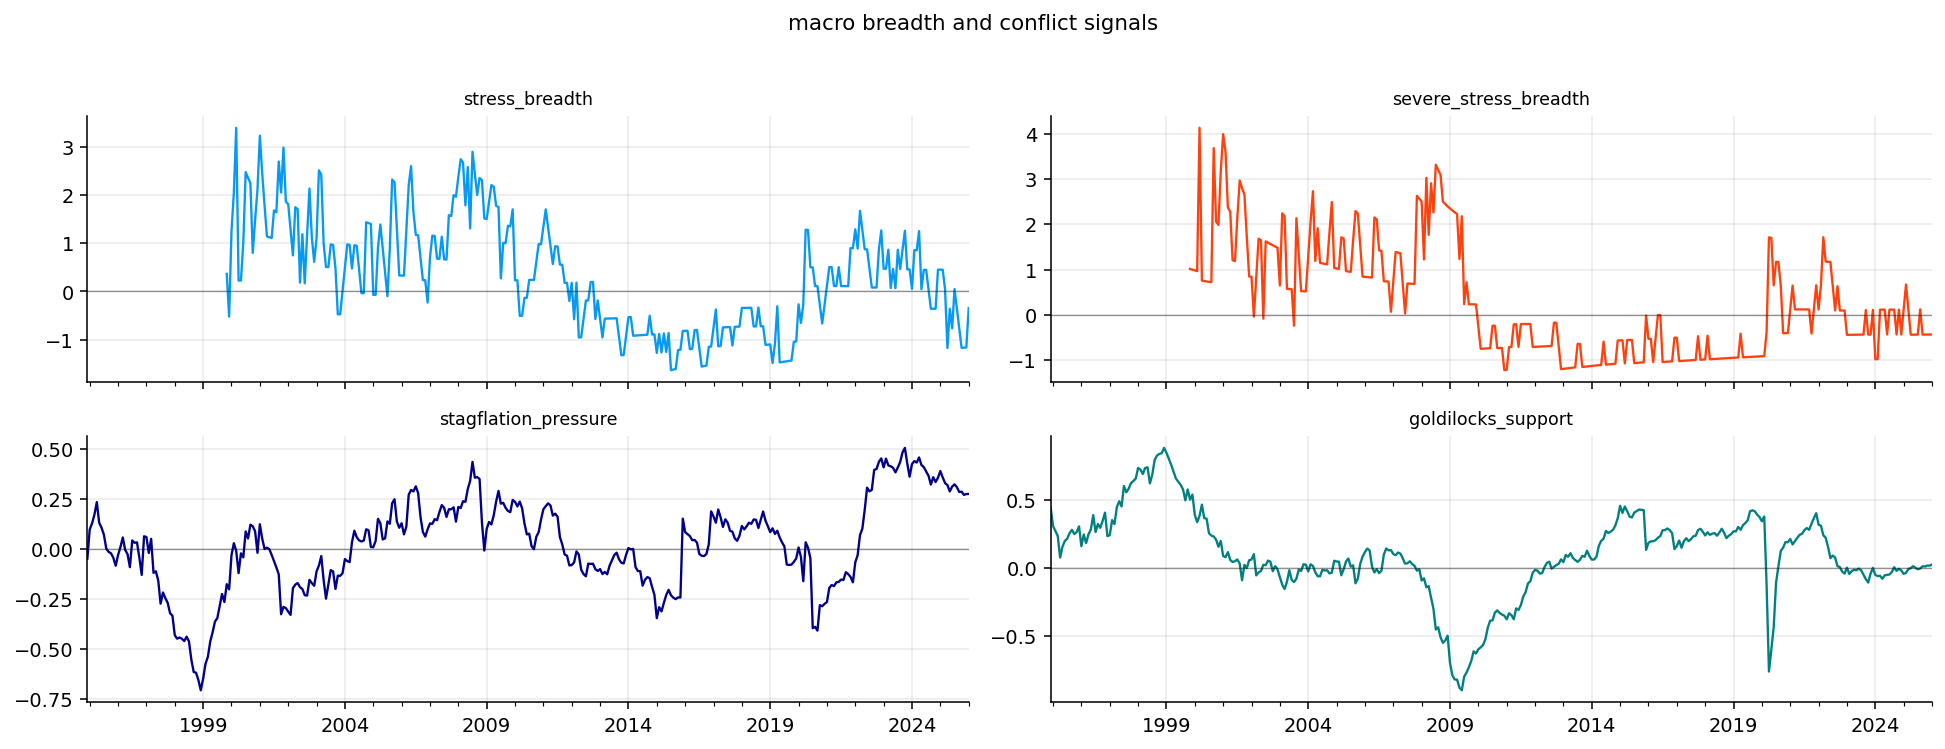

,inflation_level_pressure,inflation_impulse,inflation_acceleration,inflation_diffusion,policy_tightness,policy_shock,real_rate_squeeze,policy_catchup_risk,growth_momentum_stress,growth_acceleration_stress,growth_breadth_stress,survey_warning,labor_cooling,sahm_pressure,housing_impulse_stress,housing_rate_squeeze,external_demand_stress,external_vulnerability,stress_breadth,severe_stress_breadth,stagflation_pressure,goldilocks_support
date,,,,,,,,,,,,,,,,,,,,,,
2025-09-30,1.913833,0.572598,0.283507,-0.280186,0.333683,-0.252234,-0.238916,-0.889728,-1.389831,-0.101126,-1.302400,2.152217,-0.896948,-0.132507,-0.322739,0.005472,-0.740800,0.211200,-0.762965,-0.440632,0.285895,0.009816
2025-10-31,1.886823,0.156250,-0.341571,-0.279780,0.277807,-0.593257,0.121558,-0.847508,-1.301853,0.151222,-1.297677,2.245408,-0.894983,-0.093826,-0.220780,0.028514,-0.791354,-0.333764,-1.167479,-0.439924,0.287592,0.008051
2025-11-30,1.894163,0.242142,-0.480572,-0.279375,0.255488,-0.629775,0.013346,-0.804348,-1.336166,0.067573,-1.293005,2.414330,-0.873793,0.009136,-0.527817,-0.136164,-0.767349,0.048908,-1.163777,-0.439219,0.271162,0.015077
2025-12-31,1.887851,0.271403,-0.280847,-0.278972,0.263783,-0.377883,-0.007620,-0.822879,-1.324761,0.118781,-1.288383,2.261299,-0.885415,0.047740,-0.573187,-0.154702,-0.601934,0.335830,-1.160110,-0.438518,0.275624,0.014636
2026-01-31,1.903459,0.747146,0.588010,-0.278571,0.276304,-0.084204,-0.470842,-0.816744,-1.351111,-0.100199,-1.283811,1.998803,-0.918880,-0.081183,-0.414740,-0.069218,-0.503834,-0.163668,-0.344277,-0.437820,0.276217,0.022557


In [11]:
first_signals = pd.concat([inflation_signals, policy_signals, growth_signals, labor_signals, housing_external_signals], axis=1)
breadth_signals = pd.DataFrame(index=macro_factors.index)
breadth_signals["stress_breadth"] = expanding_zscore((first_signals > 0.5).where(first_signals.notna()).mean(axis=1, skipna=True), min_obs=min_obs)
breadth_signals["severe_stress_breadth"] = expanding_zscore((first_signals > 1.0).where(first_signals.notna()).mean(axis=1, skipna=True), min_obs=min_obs)
breadth_signals["stagflation_pressure"] = first_signals[["inflation_level_pressure", "policy_tightness", "growth_momentum_stress"]].mean(axis=1, skipna=True)
breadth_signals["goldilocks_support"] = -first_signals[["inflation_level_pressure", "policy_tightness", "growth_momentum_stress", "labor_cooling"]].mean(axis=1, skipna=True)
signals = pd.concat([first_signals, breadth_signals], axis=1)
plot_signal_group(breadth_signals, "macro breadth and conflict signals")
display(signals.tail())


In [12]:
blocks = pd.DataFrame(index=signals.index)
blocks["inflation_pressure_block"] = signals[["inflation_level_pressure", "inflation_impulse", "inflation_acceleration", "inflation_diffusion"]].mean(axis=1, skipna=True)
blocks["policy_rate_pressure_block"] = signals[["policy_tightness", "policy_shock", "real_rate_squeeze", "policy_catchup_risk"]].mean(axis=1, skipna=True)
blocks["growth_recession_block"] = signals[["growth_momentum_stress", "growth_acceleration_stress", "growth_breadth_stress", "survey_warning"]].mean(axis=1, skipna=True)
blocks["labor_cooling_block"] = signals[["labor_cooling", "sahm_pressure"]].mean(axis=1, skipna=True)
blocks["housing_domestic_block"] = signals[["housing_impulse_stress", "housing_rate_squeeze"]].mean(axis=1, skipna=True)
blocks["external_trade_block"] = signals[["external_demand_stress", "external_vulnerability"]].mean(axis=1, skipna=True)
blocks["macro_breadth_conflict_block"] = signals[["stress_breadth", "severe_stress_breadth", "stagflation_pressure"]].join(-signals["goldilocks_support"].rename("negative_goldilocks_support")).mean(axis=1, skipna=True)
macro_full = pd.concat([signals, blocks], axis=1)
macro_full["n_raw_series_used"] = macro_factors.notna().sum(axis=1)
macro_full["n_signals_available"] = signals.notna().sum(axis=1)
macro_full["n_blocks_available"] = blocks.notna().sum(axis=1)
macro_full["coverage_score"] = macro_full["n_blocks_available"] / blocks.shape[1]
macro_full = macro_full.loc[(macro_full["n_blocks_available"] >= 6) & (macro_full["n_raw_series_used"] >= 10)]
block_cols = blocks.columns.tolist()
meta_cols = ["n_raw_series_used", "n_signals_available", "n_blocks_available", "coverage_score"]
signal_cols = signals.columns.tolist()
macro_start_candidates = macro_full.index[macro_full[block_cols].notna().sum(axis=1) >= 6]
macro_start = max(macro_start_candidates[0], minimum_visible_date)
macro = macro_full.loc[macro_start:].copy()
availability_rows = []
for col in macro.columns:
    s = macro[col]
    availability_rows.append({"column": col, "first_date": s.first_valid_index(), "last_date": s.last_valid_index(), "observations": int(s.notna().sum()), "available_share": float(s.notna().mean())})
availability = pd.DataFrame(availability_rows).set_index("column")
display(pd.DataFrame({"warmup_start": [macro_full.index.min()], "analysis_start": [macro.index.min()], "end": [macro.index.max()], "rows": [len(macro)]}))
display(availability.loc[signal_cols + block_cols].round(3))


,warmup_start,analysis_start,end,rows
0,1994-12-31,1994-12-31,2026-01-31,374


,first_date,last_date,observations,available_share
column,,,,
inflation_level_pressure,1994-12-31,2026-01-31,374,1.000
inflation_impulse,1995-03-31,2026-01-31,371,0.992
inflation_acceleration,1995-06-30,2026-01-31,368,0.984
inflation_diffusion,1999-11-30,2026-01-31,315,0.842
policy_tightness,1994-12-31,2026-01-31,374,1.000
policy_shock,1995-03-31,2026-01-31,371,0.992
real_rate_squeeze,1995-03-31,2026-01-31,371,0.992
policy_catchup_risk,1999-11-30,2026-01-31,315,0.842
growth_momentum_stress,1994-12-31,2026-01-31,374,1.000


In [13]:
us_sector_assets = ["xlb", "xle", "xlf", "xli", "xlk", "xlp", "xlu", "xlv", "xly"]
optional_sector_assets = ["vnq", "iyr"]
required_defensive_assets = ["cash"]
optional_defensive_assets = ["shy", "ief", "tlt", "gld", "dbc"]
defensive_assets = required_defensive_assets + optional_defensive_assets
signal_assets = ["spy", "qqq", "iwm", "hyg", "lqd", "uup"]
etf_defensive_assets = optional_defensive_assets[:]
all_tickers = sorted(set(us_sector_assets + optional_sector_assets + etf_defensive_assets + signal_assets))
etf_data = load_yfinance_panel(etf_path, fields=("close", "volume"), tickers=all_tickers, lowercase=True)
close = etf_data["close"].ffill(limit=3)
volume = etf_data["volume"].ffill(limit=3)
daily_returns_raw = prices_to_returns(close, kind="simple")
daily_returns = daily_returns_raw.fillna(0.0).loc[daily_returns_raw.index >= macro_start]
month_key = close.index.to_period("M")
monthly_close = close.groupby(month_key).last()
monthly_close.index = monthly_close.index.to_timestamp("M")
monthly_close = monthly_close.loc[monthly_close.index >= macro_start]
returns_raw = prices_to_returns(monthly_close, kind="simple")
returns_raw["cash"] = rf_monthly
returns = returns_raw.copy()
rebalance_dates = make_rebalance_dates(daily_returns.index, freq="ME")
rebalance_months = pd.to_datetime(rebalance_dates).to_period("M").to_timestamp("M")
rebalance_months = returns.index.intersection(rebalance_months)
coverage_rows = []
for ticker in close.columns:
    prices = close[ticker].dropna()
    coverage_rows.append({"ticker": ticker, "first_price": prices.index.min(), "last_price": prices.index.max(), "price_observations": int(len(prices))})
etf_coverage = pd.DataFrame(coverage_rows).set_index("ticker")
display(etf_coverage.loc[[x for x in all_tickers if x in etf_coverage.index]])


,first_price,last_price,price_observations
ticker,,,
dbc,2006-02-06,2026-05-20,5197
gld,2004-11-18,2026-05-20,5510
hyg,2007-04-11,2026-05-20,4895
ief,2002-07-30,2026-05-20,6103
iwm,2000-05-26,2026-05-20,6661
iyr,2000-06-19,2026-05-20,6645
lqd,2002-07-30,2026-05-20,6103
qqq,1999-03-10,2026-05-20,6973
shy,2002-07-30,2026-05-20,6103


In [14]:
nfci_raw = pd.read_csv(nfci_path)
nfci_raw.columns = [str(col).lower() for col in nfci_raw.columns]
nfci_raw["date"] = pd.to_datetime(nfci_raw["friday_of_week"], errors="coerce")
nfci = nfci_raw.dropna(subset=["date"]).set_index("date").sort_index().drop(columns=["friday_of_week"])
nfci = nfci.apply(pd.to_numeric, errors="coerce")
nfci_month = nfci.groupby(nfci.index.to_period("M")).last()
nfci_month.index = nfci_month.index.to_timestamp("M")
nfci_month = nfci_month.loc[nfci_month.index >= macro_start]


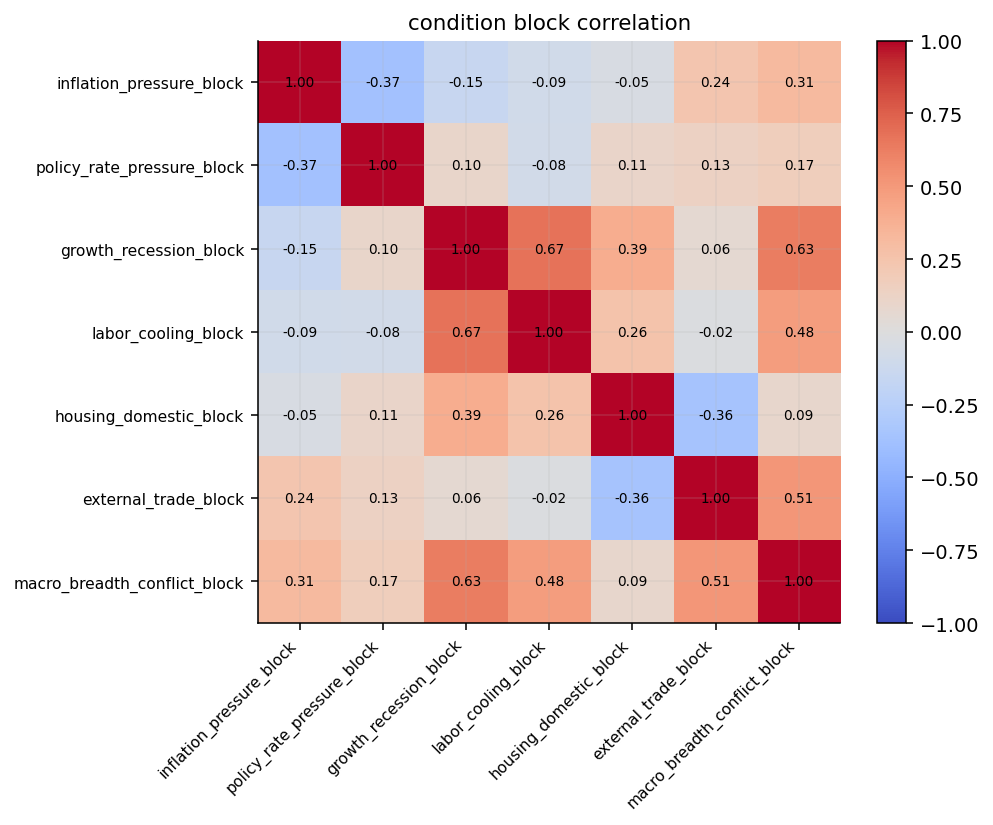

In [15]:
block_corr = macro[block_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(block_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(block_corr.columns)))
ax.set_xticklabels(block_corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(block_corr.index)))
ax.set_yticklabels(block_corr.index, fontsize=8)
for i in range(block_corr.shape[0]):
    for j in range(block_corr.shape[1]):
        value = block_corr.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("condition block correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [16]:
display(macro[block_cols].tail(12).round(2))
display(macro["macro_breadth_conflict_block"].dropna().sort_values(ascending=False).head(5).to_frame("macro_breadth_conflict_block").round(2))


,inflation_pressure_block,policy_rate_pressure_block,growth_recession_block,labor_cooling_block,housing_domestic_block,external_trade_block,macro_breadth_conflict_block
date,,,,,,,
2025-02-28,1.17,-0.36,0.02,-0.58,-0.37,0.54,0.38
2025-03-31,0.85,-0.27,0.08,-0.59,-0.08,0.66,0.12
2025-04-30,0.22,-0.12,-0.10,-0.55,-0.19,-0.16,-0.32
2025-05-31,-0.05,0.10,-0.23,-0.58,0.07,-0.05,-0.13
2025-06-30,0.65,-0.09,-0.21,-0.61,-0.08,-0.07,-0.22
2025-07-31,0.92,-0.13,-0.30,-0.59,-0.02,-0.07,-0.01
2025-08-31,0.84,-0.25,-0.14,-0.56,-0.12,-0.15,0.02
2025-09-30,0.62,-0.26,-0.16,-0.51,-0.16,-0.26,-0.23
2025-10-31,0.36,-0.26,-0.05,-0.49,-0.10,-0.56,-0.33


,macro_breadth_conflict_block
date,
2001-01-31,1.82
2000-03-31,1.78
2008-07-31,1.78
2008-08-31,1.61
2008-03-31,1.52


In [17]:
selected_dates = ["2008-10", "2020-03", "2022-09", str(macro.index.max().date())[:7]]
contribution_rows = []
for text in selected_dates:
    date = pd.to_datetime(text).to_period("M").to_timestamp("M")
    loc = macro.index.searchsorted(date, side="right") - 1
    date = macro.index[loc]
    for block, value in macro.loc[date, block_cols].items():
        contribution_rows.append({"date": date, "block": block, "value": value})
block_contribution_table = pd.DataFrame(contribution_rows).pivot(index="date", columns="block", values="value")
display(block_contribution_table.round(2))


block,external_trade_block,growth_recession_block,housing_domestic_block,inflation_pressure_block,labor_cooling_block,macro_breadth_conflict_block,policy_rate_pressure_block
date,,,,,,,
2008-10-31,0.48,1.66,0.71,-1.26,2.05,1.44,0.72
2020-03-31,-0.83,0.87,-0.13,-0.58,0.52,-0.17,-0.77
2022-09-30,-0.12,-0.01,-0.08,-0.17,-0.82,0.27,0.74
2026-01-31,-0.33,-0.18,-0.24,0.74,-0.50,-0.13,-0.27


In [18]:
def zscore(series, min_obs=60):
    series = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    mean = series.expanding(min_periods=min_obs).mean()
    std = series.expanding(min_periods=min_obs).std(ddof=1).replace(0.0, np.nan)
    return ((series - mean) / std).clip(-5, 5)

def rolling_percentile(series, min_obs=60):
    series = pd.Series(series, dtype=float)
    values = []
    for i in range(len(series)):
        sample = series.iloc[:i + 1].dropna()
        if len(sample) < min_obs or not np.isfinite(series.iloc[i]):
            values.append(np.nan)
        else:
            values.append(float((sample <= series.iloc[i]).mean()))
    return pd.Series(values, index=series.index)


In [19]:
econ_weights = pd.Series({"inflation_pressure_block": 0.18, "policy_rate_pressure_block": 0.18, "growth_recession_block": 0.18, "labor_cooling_block": 0.12, "housing_domestic_block": 0.10, "external_trade_block": 0.10, "macro_breadth_conflict_block": 0.14})
econ_data = macro_full[econ_weights.index].astype(float)
econ_weighted_sum = econ_data.mul(econ_weights, axis=1).sum(axis=1, skipna=True)
econ_available_weight = econ_data.notna().mul(econ_weights, axis=1).sum(axis=1).replace(0.0, np.nan)
fci_econ_full = zscore(econ_weighted_sum / econ_available_weight, 12).rename("fci_econ")
fci_econ = fci_econ_full.reindex(macro.index)


In [20]:
def pca_index(blocks, min_obs=60, min_cols=6):
    out = pd.Series(np.nan, index=blocks.index, name="fci_pca")
    average_stress = blocks.mean(axis=1, skipna=True)
    for date in blocks.index:
        hist = blocks.loc[:date]
        good_cols = [col for col in blocks.columns if hist[col].notna().sum() >= min_obs]
        row = blocks.loc[date, good_cols]
        good_cols = [col for col in good_cols if np.isfinite(row.get(col, np.nan))]
        if len(good_cols) < min_cols:
            continue
        sample = hist[good_cols].dropna(how="any")
        if len(sample) < min_obs:
            continue
        scaler = StandardScaler()
        train = scaler.fit_transform(sample)
        model = PCA(n_components=1)
        model.fit(train)
        current = scaler.transform(blocks.loc[[date], good_cols])
        score = float(model.transform(current)[0, 0])
        hist_score = pd.Series(model.transform(train)[:, 0], index=sample.index)
        align = pd.concat([hist_score, average_stress.reindex(sample.index)], axis=1).dropna()
        if len(align) > 12 and align.iloc[:, 0].corr(align.iloc[:, 1]) < 0:
            score = -score
        out.loc[date] = score
    return zscore(out, 12).rename("fci_pca")
fci_pca_full = pca_index(macro_full[block_cols], 36, 6)
fci_pca = fci_pca_full.reindex(macro.index)


In [21]:
spy_return = returns_raw["spy"]
future_1m_return = spy_return.shift(-1)
future_3m_return = (1.0 + spy_return.shift(-1)).rolling(3).apply(np.prod, raw=True).shift(-2) - 1.0
future_3m_volatility = spy_return.shift(-1).rolling(3).std(ddof=1).shift(-2) * np.sqrt(12.0)
future_drawdown_values = []
for i in range(len(spy_return)):
    sample = spy_return.iloc[i + 1:i + 4].dropna()
    if len(sample) < 3:
        future_drawdown_values.append(np.nan)
    else:
        nav = (1.0 + sample).cumprod()
        future_drawdown_values.append(float((nav / nav.cummax() - 1.0).min()))
future_3m_max_drawdown = pd.Series(future_drawdown_values, index=spy_return.index, name="future_3m_max_drawdown")
target_table = pd.concat([future_1m_return.rename("future_1m_return"), future_3m_return.rename("future_3m_return"), future_3m_volatility.rename("future_3m_volatility"), future_3m_max_drawdown], axis=1)
target_table["future_stress"] = zscore(-target_table["future_3m_return"], 36) + zscore(target_table["future_3m_volatility"], 36) + zscore(-target_table["future_3m_max_drawdown"], 36)
target_table = target_table.reindex(macro_full.index.union(target_table.index)).sort_index()


In [22]:
def pls_index(blocks, target, min_obs=60, min_cols=6, embargo_months=3):
    out = pd.Series(np.nan, index=blocks.index, name="fci_pls")
    target = pd.Series(target, dtype=float)
    for date in blocks.index:
        cutoff = pd.Timestamp(date) - pd.offsets.MonthEnd(embargo_months)
        hist_x = blocks.loc[blocks.index < cutoff]
        hist_y = target.reindex(hist_x.index)
        good_cols = [col for col in blocks.columns if hist_x[col].notna().sum() >= min_obs]
        row = blocks.loc[date, good_cols]
        good_cols = [col for col in good_cols if np.isfinite(row.get(col, np.nan))]
        if len(good_cols) < min_cols:
            continue
        train = pd.concat([hist_x[good_cols], hist_y.rename("target")], axis=1).dropna()
        if len(train) < min_obs:
            continue
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train[good_cols])
        components = min(2, len(good_cols), len(train) - 1)
        model = PLSRegression(n_components=components)
        model.fit(train_x, train["target"].to_numpy(dtype=float))
        current = scaler.transform(blocks.loc[[date], good_cols])
        prediction = np.asarray(model.predict(current), dtype=float).reshape(-1)
        out.loc[date] = float(prediction[0])
    return zscore(out, 36).rename("fci_pls")
fci_pls_full = pls_index(macro_full[block_cols], target_table["future_stress"], 36, 6, 3)
fci_pls = fci_pls_full.reindex(macro.index)


In [23]:
def prob_index(features, target, min_obs=60, embargo_months=3):
    x = features.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    y = pd.Series(target, dtype=float).reindex(x.index)
    threshold = y.expanding(min_periods=min_obs).quantile(0.75).shift(1)
    label = (y > threshold).where(threshold.notna())
    out = pd.Series(np.nan, index=x.index, name="fci_prob")
    for date in x.index:
        current = x.loc[date].dropna()
        cutoff = pd.Timestamp(date) - pd.offsets.MonthEnd(embargo_months)
        history = x.loc[x.index < cutoff]
        cols = [col for col in current.index if history[col].notna().sum() >= min_obs]
        if len(cols) < 4:
            continue
        train = pd.concat([history[cols], label.loc[history.index].rename("label")], axis=1).dropna()
        if len(train) < min_obs or train["label"].nunique() < 2:
            continue
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train[cols])
        model = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs")
        model.fit(train_x, train["label"].astype(int))
        current_x = scaler.transform(x.loc[[date], cols])
        out.loc[date] = float(model.predict_proba(current_x)[0, 1])
    return out
prob_features = pd.concat([macro_full[block_cols], fci_econ_full, fci_pca_full, fci_pls_full], axis=1)
fci_prob_full = prob_index(prob_features, target_table["future_stress"], 36, 3)
fci_prob_z_full = zscore(fci_prob_full, 12).rename("fci_prob")
fci_prob_z = fci_prob_z_full.reindex(macro.index)


,first_date,last_date,observations
fci_econ,1995-11-30,2026-01-31,363
fci_pca,1998-10-31,2026-01-31,328
fci_pls,2008-03-31,2026-01-31,215
fci_prob,2009-03-31,2026-01-31,203
fci_blend,2009-02-28,2026-01-31,204


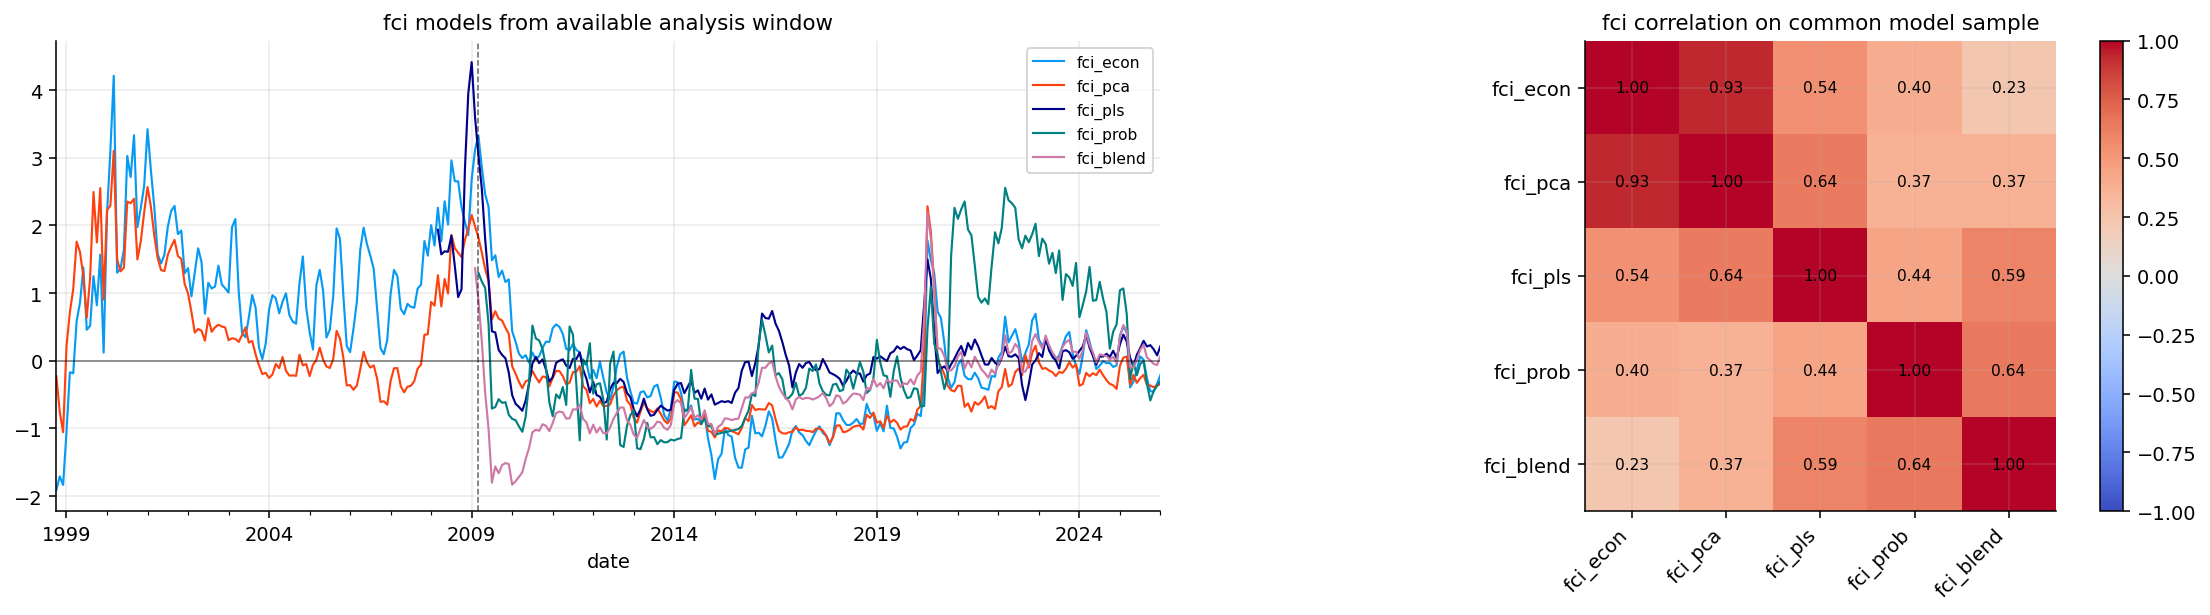

In [24]:
fci_blend_full = zscore(0.50 * fci_pls_full + 0.30 * fci_pca_full + 0.20 * fci_econ_full, 12).rename("fci_blend")
fci_blend = fci_blend_full.reindex(macro.index)
fci_models = pd.concat([fci_econ, fci_pca, fci_pls, fci_prob_z, fci_blend], axis=1).reindex(macro.index)
fci_availability = pd.DataFrame({
    "first_date": fci_models.apply(pd.Series.first_valid_index),
    "last_date": fci_models.apply(pd.Series.last_valid_index),
    "observations": fci_models.notna().sum(),
})
fci_plot_start = fci_models.dropna(thresh=2).index.min()
fci_common_start = fci_models.dropna(how="any").index.min()
fci_common = fci_models.loc[fci_common_start:].dropna(how="any") if pd.notna(fci_common_start) else pd.DataFrame()
display(fci_availability)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
fci_models.loc[fci_plot_start:].plot(ax=axes[0], lw=1.1, color=colors[:len(fci_models.columns)])
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
if pd.notna(fci_common_start):
    axes[0].axvline(fci_common_start, color="black", lw=0.8, ls="--", alpha=0.6)
axes[0].set_title("fci models from available analysis window")
axes[0].grid(True, alpha=0.25)
fci_corr = fci_common.corr() if len(fci_common) else fci_models.corr()
im = axes[1].imshow(fci_corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(fci_corr.columns)))
axes[1].set_xticklabels(fci_corr.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(fci_corr.columns)))
axes[1].set_yticklabels(fci_corr.columns)
for i in range(fci_corr.shape[0]):
    for j in range(fci_corr.shape[1]):
        value = fci_corr.iloc[i, j]
        if np.isfinite(value):
            axes[1].text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_title("fci correlation on common model sample")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


,date,value,percentile,change_3m,interpretation
model,,,,,
fci_econ,2026-01-31,-0.208,0.386,0.242,neutral
fci_pca,2026-01-31,-0.349,0.439,0.019,neutral
fci_pls,2026-01-31,0.218,0.814,-0.013,tight
fci_prob,2026-01-31,-0.297,0.483,0.289,neutral
fci_blend,2026-01-31,0.070,0.809,0.065,tight


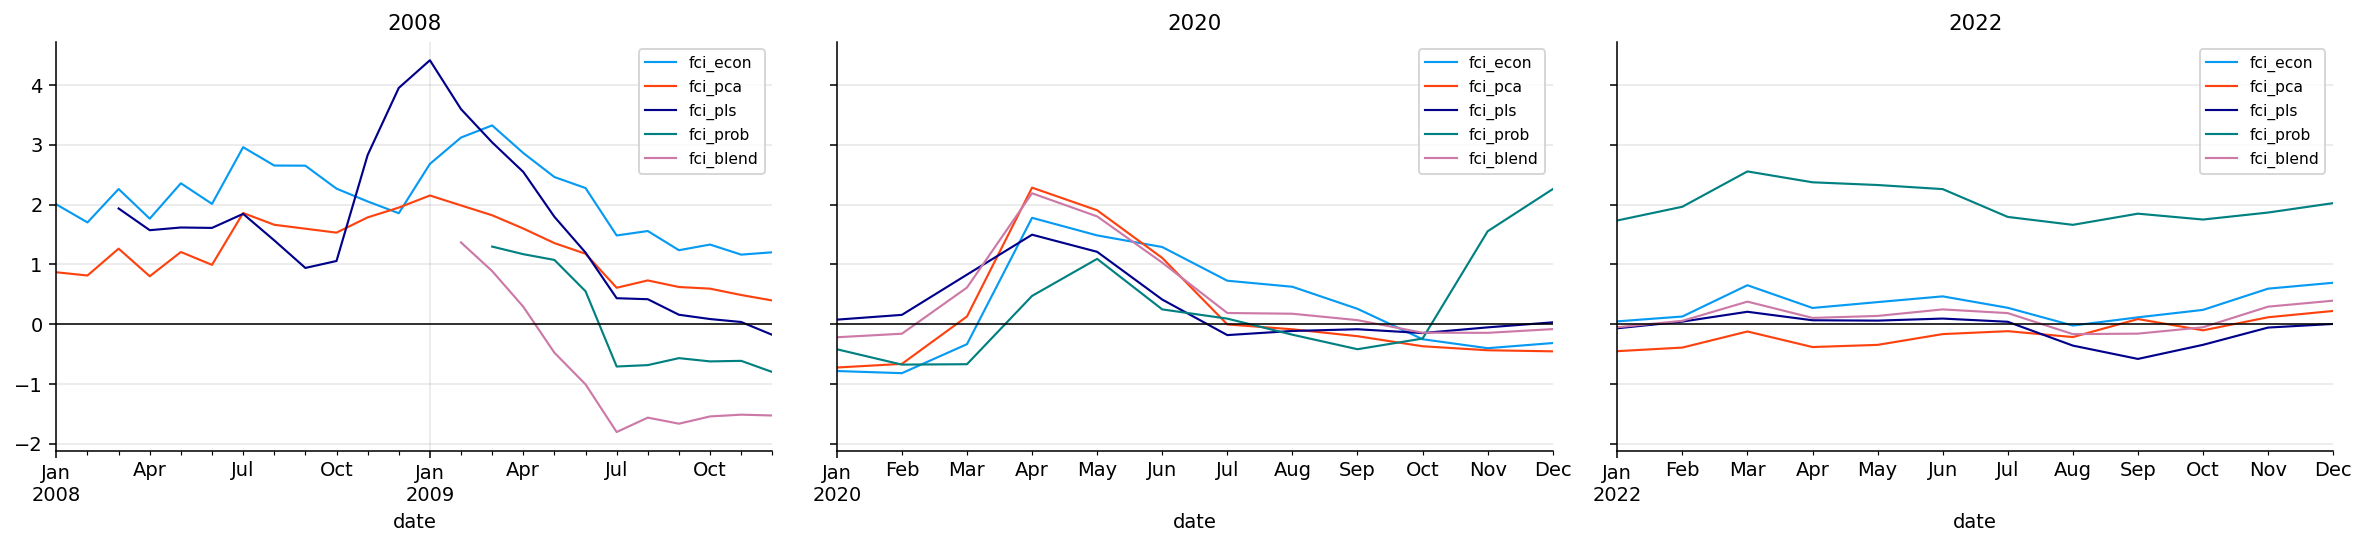

In [25]:
latest_rows = []
for col in fci_models.columns:
    series = fci_models[col].dropna()
    if series.empty:
        continue
    pct = rolling_percentile(fci_models[col], 60)
    change = fci_models[col].diff(3)
    date = series.index.max()
    latest_pct = float(pct.loc[date]) if np.isfinite(pct.loc[date]) else np.nan
    interpretation = "tight" if latest_pct >= 0.8 else "easy" if latest_pct <= 0.2 else "neutral"
    latest_rows.append({"model": col, "date": date, "value": float(series.loc[date]), "percentile": latest_pct, "change_3m": change.loc[date], "interpretation": interpretation})
latest_fci_table = pd.DataFrame(latest_rows).set_index("model")
display(latest_fci_table.round(3))
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, start, end, title in zip(axes, ["2008-01", "2020-01", "2022-01"], ["2009-12", "2020-12", "2022-12"], ["2008", "2020", "2022"]):
    fci_models.loc[start:end].plot(ax=ax, lw=1.1)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
nfci_validation = pd.concat([nfci_month["nfci"], fci_models], axis=1).loc[macro_start:].dropna(subset=["nfci"])


In [27]:
crisis_windows = {"financial_crisis": ("2008-09", "2009-03"), "covid_crash": ("2020-02", "2020-04"), "inflation_rate_shock": ("2022-01", "2022-10")}


In [28]:
def quintile_report(fci, target):
    data = pd.concat([fci.rename("fci"), target], axis=1).dropna(subset=["fci", "future_stress"])
    if len(data) < 30:
        return pd.DataFrame()
    ranks = data["fci"].rank(method="first")
    data["fci_quintile"] = pd.qcut(ranks, 5, labels=["q1", "q2", "q3", "q4", "q5"])
    report = data.groupby("fci_quintile", observed=False)[["future_1m_return", "future_3m_return", "future_3m_volatility", "future_3m_max_drawdown", "future_stress"]].mean()
    report["observations"] = data.groupby("fci_quintile", observed=False).size()
    return report
quintile_reports = {name: quintile_report(fci_models[name], target_table) for name in fci_models.columns}
for name, report in quintile_reports.items():
    print(name)
    display(report.round(4))


fci_econ


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0141,0.0257,0.0975,-0.0216,-0.5985,58
q2,0.0119,0.0426,0.1248,-0.0167,-0.6338,58
q3,0.0116,0.0369,0.1319,-0.0247,-0.4533,57
q4,0.0055,0.0201,0.1171,-0.0228,-0.6806,58
q5,0.0004,0.0065,0.1443,-0.0399,0.1867,58


fci_pca


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0128,0.0240,0.0974,-0.0220,-0.5626,58
q2,0.0074,0.0344,0.1203,-0.0182,-0.5884,58
q3,0.0147,0.0330,0.1118,-0.0228,-0.6833,57
q4,0.0067,0.0310,0.1287,-0.0215,-0.5822,58
q5,0.0021,0.0092,0.1570,-0.0411,0.2331,58


fci_pls


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0114,0.0301,0.1194,-0.0228,-0.5173,43
q2,0.0102,0.0305,0.1221,-0.0213,-0.4201,43
q3,0.0083,0.0248,0.1310,-0.0294,-0.0475,43
q4,0.0156,0.0440,0.1417,-0.0221,-0.2875,43
q5,0.0057,0.0227,0.1472,-0.0352,0.3002,43


fci_prob


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0124,0.0305,0.1192,-0.0209,-0.5660,41
q2,0.0104,0.0379,0.1112,-0.0143,-0.8600,40
q3,0.0103,0.0314,0.1242,-0.0256,-0.2704,41
q4,0.0184,0.0489,0.1269,-0.0199,-0.6446,40
q5,0.0138,0.0400,0.1497,-0.0284,0.0154,41


fci_blend


,future_1m_return,future_3m_return,future_3m_volatility,future_3m_max_drawdown,future_stress,observations
fci_quintile,,,,,,
q1,0.0162,0.0457,0.1289,-0.0199,-0.7391,41
q2,0.0096,0.0248,0.1085,-0.0215,-0.5906,41
q3,0.0087,0.0282,0.1035,-0.0206,-0.5562,40
q4,0.0151,0.0308,0.1334,-0.0260,-0.0889,41
q5,0.0170,0.0642,0.1553,-0.0206,-0.4411,41


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score,long_history_eligible
model,,,,,,,,,,,,,,,
fci_pca,328,1998-10-31,2026-01-31,0.0384,0.0191,0.3,0.0596,0.7616,0.6,1.0,0.3,1.0,0.6,0.70,True
fci_prob,203,2009-03-31,2026-01-31,0.0413,0.0076,0.5,0.0305,0.7270,1.0,0.4,0.6,0.6,0.4,0.65,False
fci_econ,363,1995-11-30,2026-01-31,0.0413,0.0183,0.3,0.0468,0.6786,0.8,0.8,0.3,0.8,0.2,0.64,True
fci_pls,215,2008-03-31,2026-01-31,0.0208,0.0124,0.9,0.0278,0.7994,0.2,0.6,0.9,0.4,0.8,0.53,False
fci_blend,204,2009-02-28,2026-01-31,0.0223,0.0007,0.9,0.0264,0.8201,0.4,0.2,0.9,0.2,1.0,0.48,False


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score
model,,,,,,,,,,,,,,
fci_econ,203,2009-03-31,2026-01-31,0.0645,0.0072,0.3,0.0642,0.7928,1.0,0.8,0.4,1.0,0.4,0.77
fci_prob,203,2009-03-31,2026-01-31,0.0413,0.0076,0.5,0.0305,0.7270,0.8,1.0,0.7,0.6,0.2,0.74
fci_blend,203,2009-03-31,2026-01-31,0.0375,0.0007,0.9,0.0258,0.8214,0.6,0.4,1.0,0.4,0.8,0.62
fci_pca,203,2009-03-31,2026-01-31,0.0202,0.0009,0.5,0.0555,0.8122,0.4,0.6,0.7,0.8,0.6,0.59
fci_pls,203,2009-03-31,2026-01-31,-0.1044,-0.0127,-0.1,-0.0166,0.8410,0.2,0.2,0.2,0.2,1.0,0.28


,model_split_date,train_months,test_months
0,2020-02-29,131,72


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score
model,,,,,,,,,,,,,,
fci_econ,72,2020-02-29,2026-01-31,0.1531,0.0236,0.9,0.0690,0.7424,0.8,0.8,1.0,1.0,0.6,0.85
fci_prob,72,2020-02-29,2026-01-31,0.1642,0.0273,0.7,0.0258,0.6984,1.0,1.0,0.8,0.8,0.2,0.85
fci_blend,72,2020-02-29,2026-01-31,-0.1208,-0.0010,0.0,-0.0159,0.7707,0.6,0.6,0.6,0.4,0.8,0.59
fci_pca,72,2020-02-29,2026-01-31,-0.1213,-0.0089,-0.2,0.0056,0.7406,0.4,0.4,0.4,0.6,0.4,0.43
fci_pls,72,2020-02-29,2026-01-31,-0.2907,-0.0172,-0.8,-0.0531,0.8243,0.2,0.2,0.2,0.2,1.0,0.28


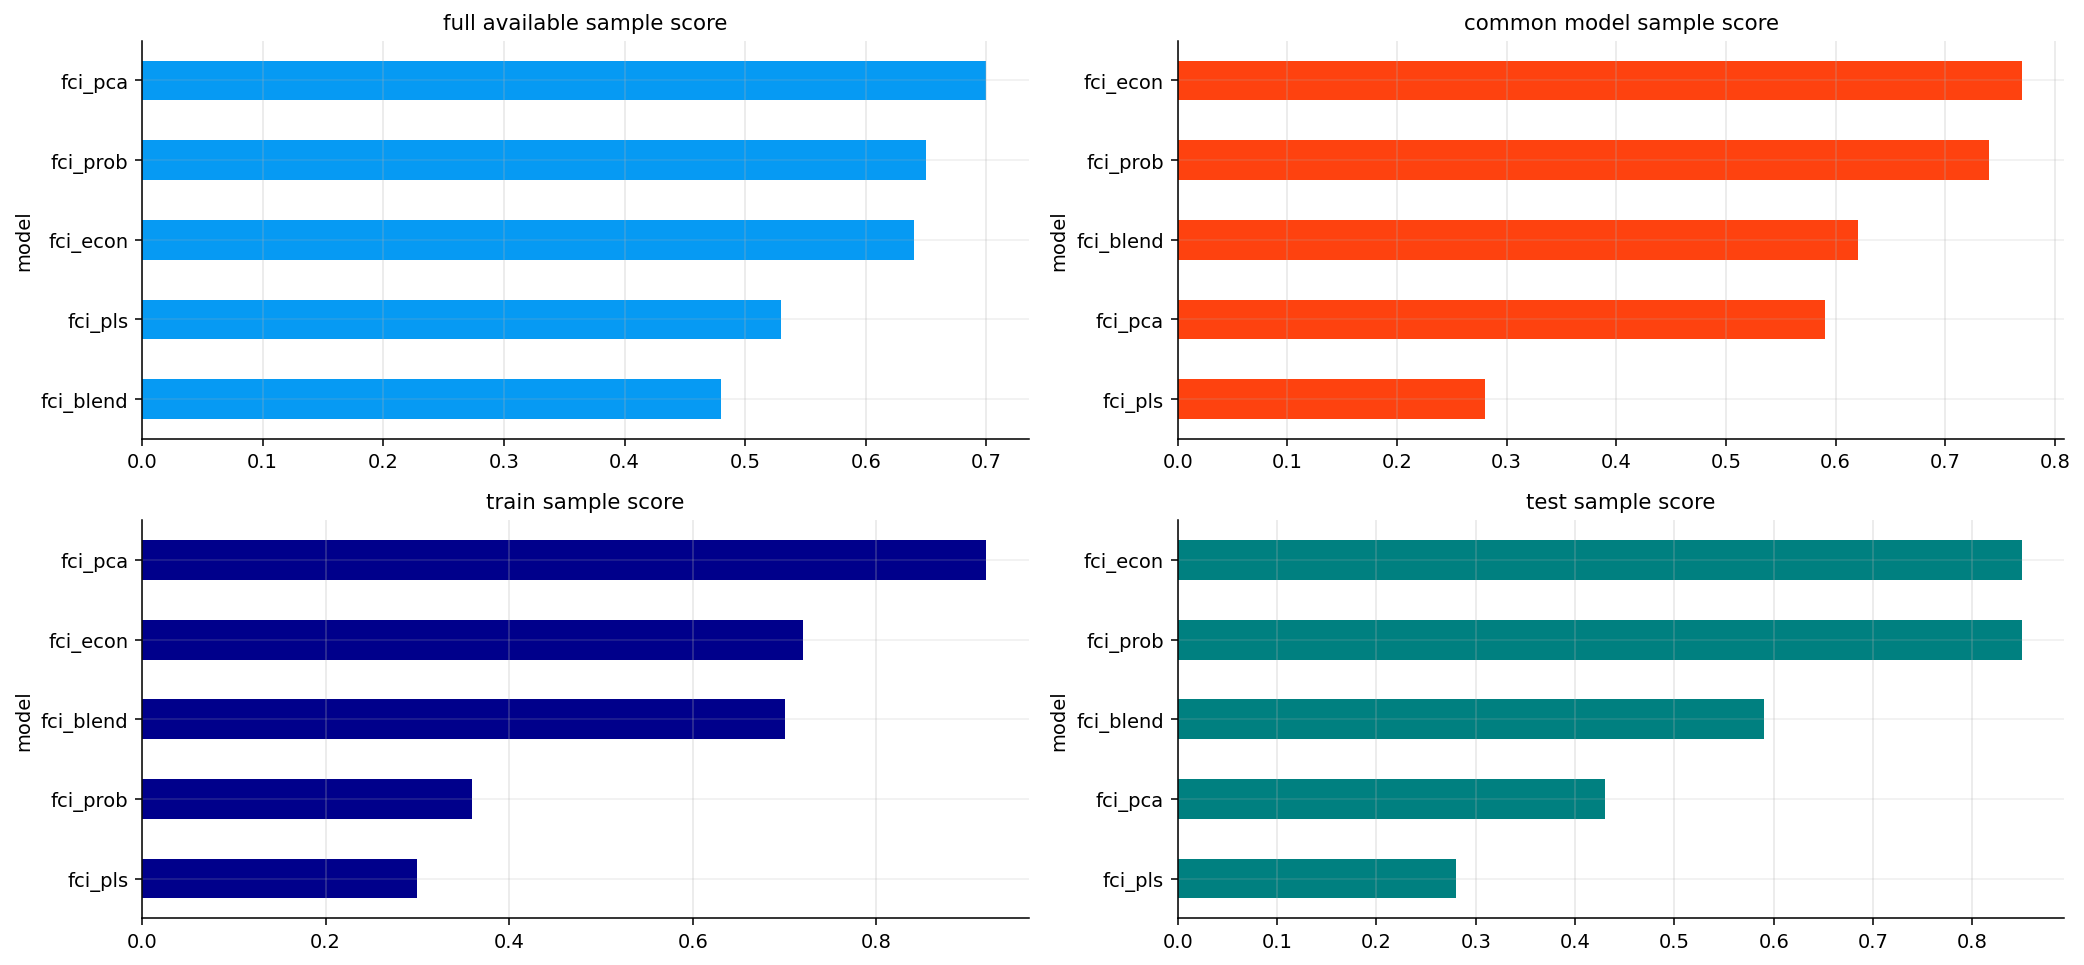

In [29]:
def score_fci_models(models, target):
    rows = []
    for name in models.columns:
        report = quintile_report(models[name], target)
        pair = pd.concat([models[name].rename("fci"), target["future_stress"]], axis=1).dropna()
        rank_ic = pair["fci"].rank().corr(pair["future_stress"].rank()) if len(pair) >= 20 else np.nan
        if report.empty:
            rows.append({"model": name, "observations": int(models[name].notna().sum()), "first_valid_date": models[name].first_valid_index(), "last_valid_date": models[name].last_valid_index(), "future_stress_rank_ic": rank_ic})
            continue
        y = report["future_stress"].dropna()
        monotonicity = pd.Series(range(1, len(y) + 1), index=y.index).corr(y.rank()) if len(y) >= 3 else np.nan
        rows.append({"model": name, "observations": int(models[name].notna().sum()), "first_valid_date": models[name].first_valid_index(), "last_valid_date": models[name].last_valid_index(), "future_stress_rank_ic": rank_ic, "drawdown_spread": report.loc["q1", "future_3m_max_drawdown"] - report.loc["q5", "future_3m_max_drawdown"], "monotonicity_score": monotonicity, "volatility_spread": report.loc["q5", "future_3m_volatility"] - report.loc["q1", "future_3m_volatility"], "stability_score": 1.0 / (1.0 + models[name].diff().std())})
    scores = pd.DataFrame(rows).set_index("model") if rows else pd.DataFrame()
    for col in ["future_stress_rank_ic", "drawdown_spread", "monotonicity_score", "volatility_spread", "stability_score"]:
        if col in scores:
            scores[col + "_rank"] = scores[col].rank(pct=True)
    if len(scores):
        scores["final_score"] = 0.30 * scores["future_stress_rank_ic_rank"] + 0.25 * scores["drawdown_spread_rank"] + 0.20 * scores["monotonicity_score_rank"] + 0.15 * scores["volatility_spread_rank"] + 0.10 * scores["stability_score_rank"]
        scores = scores.sort_values("final_score", ascending=False)
    return scores

full_sample_scoreboard = score_fci_models(fci_models, target_table)
full_sample_scoreboard["long_history_eligible"] = (full_sample_scoreboard["observations"] >= 180) & (full_sample_scoreboard["first_valid_date"] <= pd.Timestamp("2000-12-31"))
common_model_index = pd.concat([fci_models, target_table["future_stress"]], axis=1).dropna().index
common_model_scoreboard = score_fci_models(fci_models.reindex(common_model_index), target_table.reindex(common_model_index))
model_split_date = common_model_index[int(len(common_model_index) * 0.65)] if len(common_model_index) else pd.NaT
train_model_index = common_model_index[common_model_index < model_split_date]
test_model_index = common_model_index[common_model_index >= model_split_date]
train_model_scoreboard = score_fci_models(fci_models.reindex(train_model_index), target_table.reindex(train_model_index))
test_model_scoreboard = score_fci_models(fci_models.reindex(test_model_index), target_table.reindex(test_model_index))
display(full_sample_scoreboard.round(4))
display(common_model_scoreboard.round(4))
display(pd.DataFrame({"model_split_date": [model_split_date], "train_months": [len(train_model_index)], "test_months": [len(test_model_index)]}))
display(test_model_scoreboard.round(4))
fig, axes = plt.subplots(2, 2, figsize=(15, 7))
full_sample_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[0, 0], color=colors[0])
common_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[0, 1], color=colors[1])
train_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[1, 0], color=colors[2])
test_model_scoreboard["final_score"].sort_values().plot(kind="barh", ax=axes[1, 1], color=colors[3])
for ax, title in zip(axes.ravel(), ["full available sample score", "common model sample score", "train sample score", "test sample score"]):
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


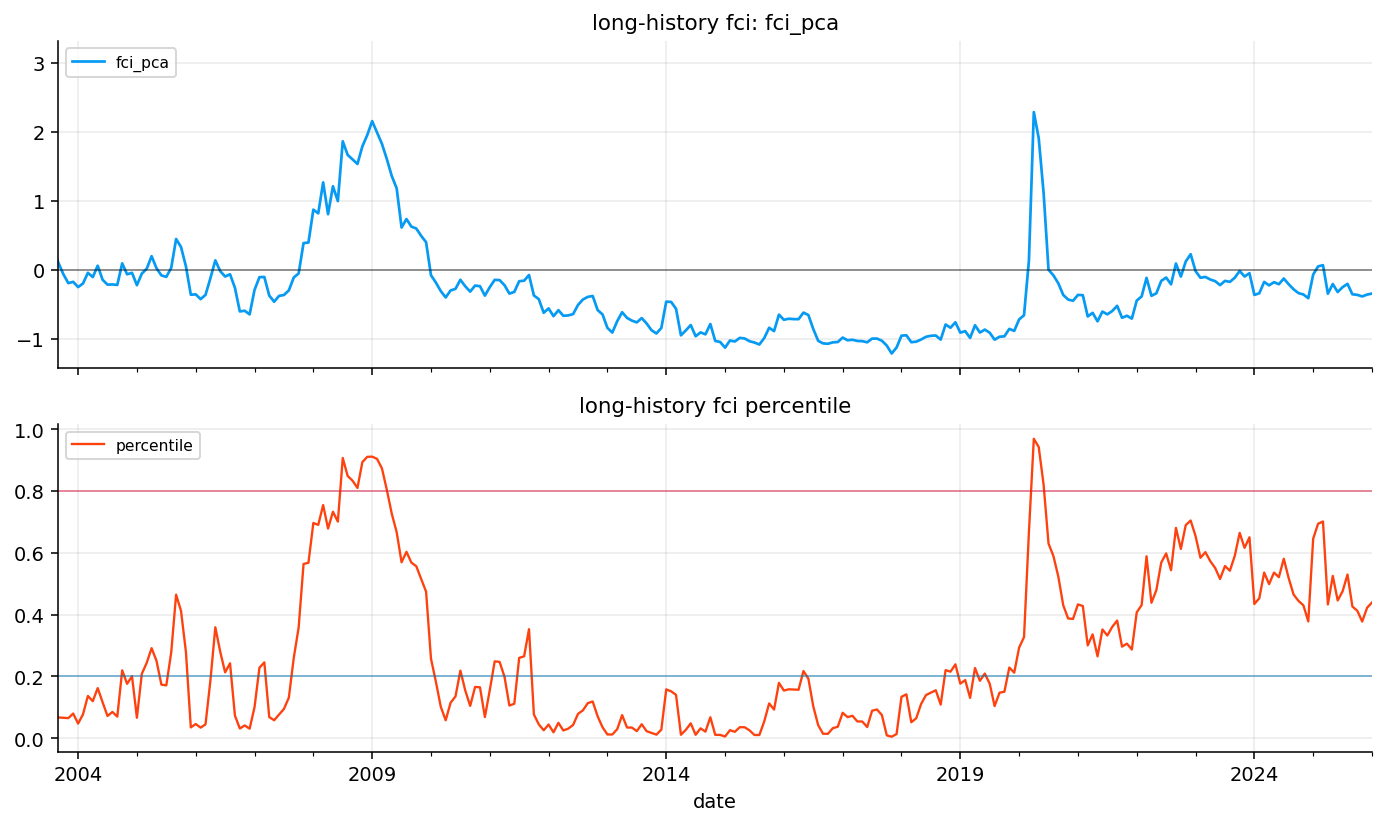

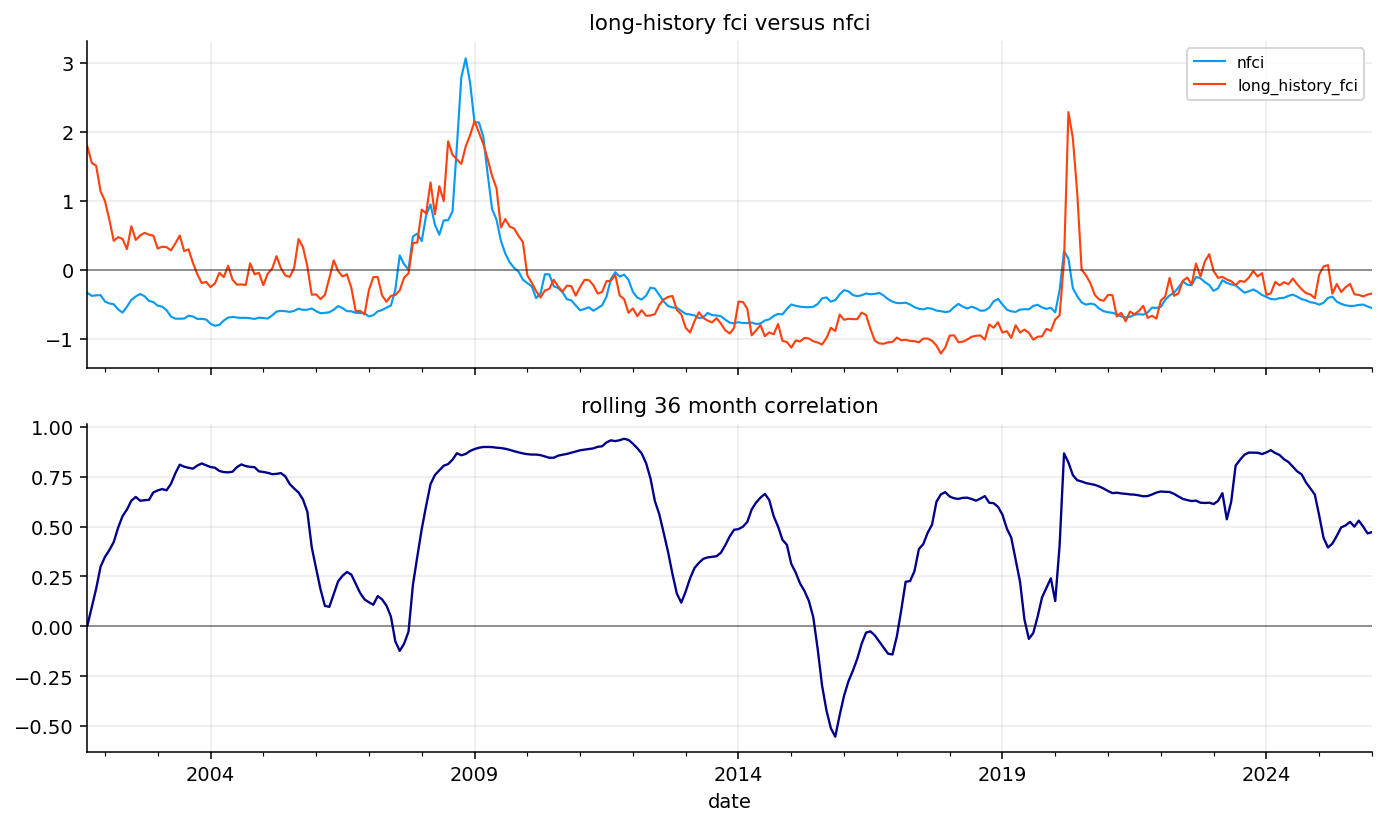

,correlation_with_nfci
selected_fci_model,
fci_pca,0.531


,mean_selected_fci,mean_nfci,agreement
window,,,
financial_crisis,1.833,2.364,1.0
covid_crash,0.584,0.043,1.0
inflation_rate_shock,-0.219,-0.281,0.9


In [30]:
long_history_scoreboard = full_sample_scoreboard.loc[full_sample_scoreboard["long_history_eligible"]]
long_history_fci_name = long_history_scoreboard.index[0] if len(long_history_scoreboard) else full_sample_scoreboard.index[0]
long_history_fci_series = fci_models[long_history_fci_name].rename("long_history_fci")
long_history_fci_percentile = rolling_percentile(long_history_fci_series, 60).rename("long_history_fci_percentile")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
long_history_fci_series.dropna().plot(ax=axes[0], lw=1.4, color=colors[0], label=long_history_fci_name)
long_history_fci_percentile.dropna().plot(ax=axes[1], lw=1.2, color=colors[1], label="percentile")
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[1].axhline(0.8, color=colors[5], lw=0.8, alpha=0.6)
axes[1].axhline(0.2, color=colors[7], lw=0.8, alpha=0.6)
axes[0].set_title("long-history fci: " + long_history_fci_name)
axes[1].set_title("long-history fci percentile")
for ax in axes:
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
selected_nfci = pd.concat([nfci_month["nfci"], long_history_fci_series], axis=1).dropna()
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
selected_nfci.plot(ax=axes[0], lw=1.1, color=[colors[0], colors[1]])
axes[0].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[0].set_title("long-history fci versus nfci")
rolling_selected_nfci_corr = selected_nfci["long_history_fci"].rolling(36).corr(selected_nfci["nfci"])
rolling_selected_nfci_corr.dropna().plot(ax=axes[1], lw=1.2, color=colors[2])
axes[1].axhline(0.0, color="black", lw=0.8, alpha=0.5)
axes[1].set_title("rolling 36 month correlation")
for ax in axes:
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
nfci_corr = pd.DataFrame({"selected_fci_model": [long_history_fci_name], "correlation_with_nfci": [selected_nfci["long_history_fci"].corr(selected_nfci["nfci"])]}).set_index("selected_fci_model")
display(nfci_corr.round(3))
crisis_rows = []
for name, dates in crisis_windows.items():
    window = selected_nfci.loc[dates[0]:dates[1]]
    if len(window):
        crisis_rows.append({"window": name, "mean_selected_fci": window["long_history_fci"].mean(), "mean_nfci": window["nfci"].mean(), "agreement": float((np.sign(window["long_history_fci"]) == np.sign(window["nfci"])).mean())})
crisis_agreement_table = pd.DataFrame(crisis_rows).set_index("window")
display(crisis_agreement_table.round(3))


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,future_stress_rank_ic_rank,drawdown_spread_rank,monotonicity_score_rank,volatility_spread_rank,stability_score_rank,final_score,strategy_test_sample
model,,,,,,,,,,,,,,,
fci_econ,112,2016-10-31,2026-01-31,0.1950,0.0198,0.4,0.1163,0.7749,1.0,0.8,0.9,1.0,0.4,0.87,True
fci_prob,112,2016-10-31,2026-01-31,0.1456,0.0230,0.3,0.0381,0.7322,0.8,1.0,0.6,0.4,0.2,0.69,True
fci_pca,112,2016-10-31,2026-01-31,0.0822,0.0128,0.1,0.0905,0.7790,0.6,0.6,0.4,0.8,0.6,0.59,True
fci_blend,112,2016-10-31,2026-01-31,0.0562,0.0085,0.4,0.0835,0.8051,0.4,0.4,0.9,0.6,0.8,0.57,True
fci_pls,112,2016-10-31,2026-01-31,-0.1588,-0.0139,-0.7,-0.0274,0.8466,0.2,0.2,0.2,0.2,1.0,0.28,True


,full_sample_score_winner,common_sample_score_winner,test_sample_score_winner,selected_strategy_fci,selection_rule
0,fci_pca,fci_econ,fci_econ,fci_pca,Pre-specified long-history unsupervised FCI se...


,long_history_fci,prespecified_strategy_fci,strategy_start,strategy_test_start
0,fci_pca,fci_pca,1999-07-31,2016-10-31


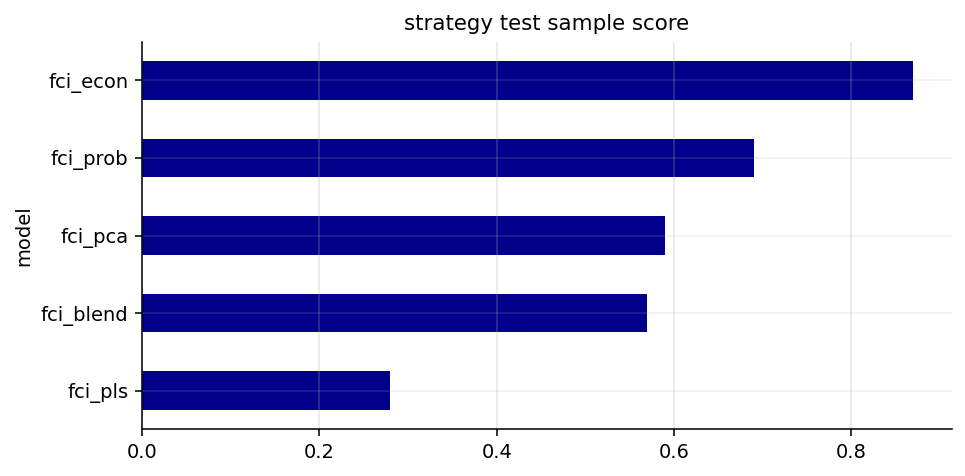

In [31]:
sector_assets = us_sector_assets[:]
defensive_sector_assets = [x for x in ["xlp", "xlu", "xlv"] if x in returns.columns]
cyclical_sector_assets = [x for x in ["xlf", "xli", "xly", "xlb"] if x in returns.columns]
inflation_assets = [x for x in ["xle", "xlb", "dbc", "gld"] if x in returns.columns]
rate_sensitive_assets = [x for x in ["xlk", "xly", "tlt"] if x in returns.columns]
strategy_assets = sorted(set(sector_assets + defensive_assets + ["spy"]))
required_strategy_assets = sector_assets + ["spy", "cash"]
asset_first_month = monthly_close[sector_assets + ["spy"]].apply(pd.Series.first_valid_index)
strategy_start = max(macro_start, asset_first_month.max() + pd.offsets.MonthEnd(6))
score_strategy_dates = fci_models.index.intersection(returns.index)
score_strategy_dates = score_strategy_dates[score_strategy_dates >= strategy_start]
strategy_split_date = score_strategy_dates[int(len(score_strategy_dates) * 0.65)] if len(score_strategy_dates) else pd.NaT
strategy_test_dates = score_strategy_dates[score_strategy_dates >= strategy_split_date]
strategy_sample_scoreboard = score_fci_models(fci_models.reindex(strategy_test_dates), target_table.reindex(strategy_test_dates))
strategy_sample_scoreboard["strategy_test_sample"] = True
prespecified_strategy_fci_name = long_history_fci_name
strategy_fci_name = prespecified_strategy_fci_name if prespecified_strategy_fci_name in fci_models.columns else "fci_econ"
best_fci_name = strategy_fci_name
best_fci_series = fci_models[best_fci_name].rename("best_fci")
best_fci_percentile = rolling_percentile(best_fci_series, 60).rename("best_fci_percentile")
best_fci_3m_change = best_fci_series.diff(3).rename("best_fci_3m_change")
tradable_macro = macro.shift(1)
allocation_features = tradable_macro[["inflation_pressure_block", "policy_rate_pressure_block", "growth_recession_block", "macro_breadth_conflict_block", "goldilocks_support"]].copy()
allocation_features["best_fci_percentile"] = best_fci_percentile.shift(1)
allocation_features["best_fci_3m_change"] = best_fci_3m_change.shift(1)
allocation_features["best_fci_value"] = best_fci_series.shift(1)
dominant_block_values = tradable_macro[block_cols].abs()
dominant_macro_block = pd.Series(np.nan, index=dominant_block_values.index, dtype=object)
has_dominant_block = dominant_block_values.notna().any(axis=1)
dominant_macro_block.loc[has_dominant_block] = dominant_block_values.loc[has_dominant_block].idxmax(axis=1)
allocation_features["dominant_macro_block"] = dominant_macro_block
allocation_features = allocation_features.dropna(subset=["best_fci_percentile", "best_fci_3m_change"])
model_choice_table = pd.DataFrame({
    "full_sample_score_winner": [full_sample_scoreboard.index[0]],
    "common_sample_score_winner": [common_model_scoreboard.index[0]],
    "test_sample_score_winner": [test_model_scoreboard.index[0]],
    "selected_strategy_fci": [strategy_fci_name],
    "selection_rule": ["Pre-specified long-history unsupervised FCI selected to avoid supervised model-selection lookahead and preserve crisis coverage."],
})
display(strategy_sample_scoreboard.round(4))
display(model_choice_table)
display(pd.DataFrame({"long_history_fci": [long_history_fci_name], "prespecified_strategy_fci": [strategy_fci_name], "strategy_start": [strategy_start], "strategy_test_start": [strategy_split_date]}))
fig, ax = plt.subplots(figsize=(7, 3.5))
strategy_sample_scoreboard["final_score"].sort_values().plot(kind="barh", ax=ax, color=colors[2])
ax.set_title("strategy test sample score")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


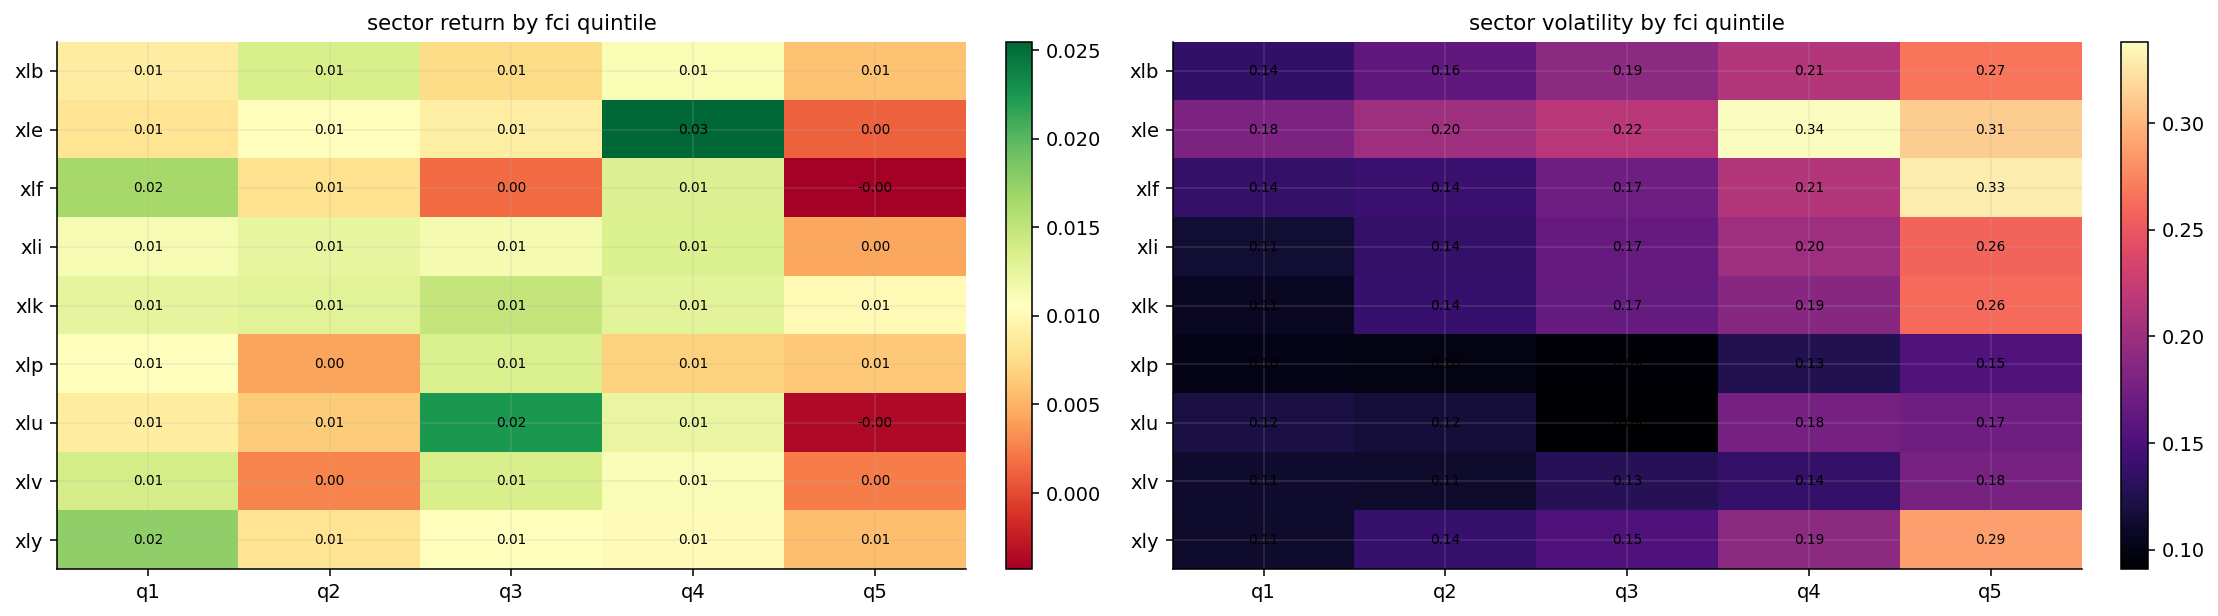

In [32]:
regime_data = pd.concat([best_fci_percentile.rename("fci_percentile"), returns[sector_assets].shift(-1)], axis=1).dropna(subset=["fci_percentile"])
regime_data["fci_quintile"] = pd.qcut(regime_data["fci_percentile"].rank(method="first"), 5, labels=["q1", "q2", "q3", "q4", "q5"])
sector_return_by_regime = regime_data.groupby("fci_quintile", observed=False)[sector_assets].mean()
sector_vol_by_regime = regime_data.groupby("fci_quintile", observed=False)[sector_assets].std() * np.sqrt(12.0)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, table, title, cmap in [(axes[0], sector_return_by_regime, "sector return by fci quintile", "RdYlGn"), (axes[1], sector_vol_by_regime, "sector volatility by fci quintile", "magma")]:
    shown = table.transpose()
    im = ax.imshow(shown, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(shown.columns)))
    ax.set_xticklabels(shown.columns)
    ax.set_yticks(range(len(shown.index)))
    ax.set_yticklabels(shown.index)
    for row in range(shown.shape[0]):
        for col in range(shown.shape[1]):
            value = shown.iloc[row, col]
            if np.isfinite(value):
                ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


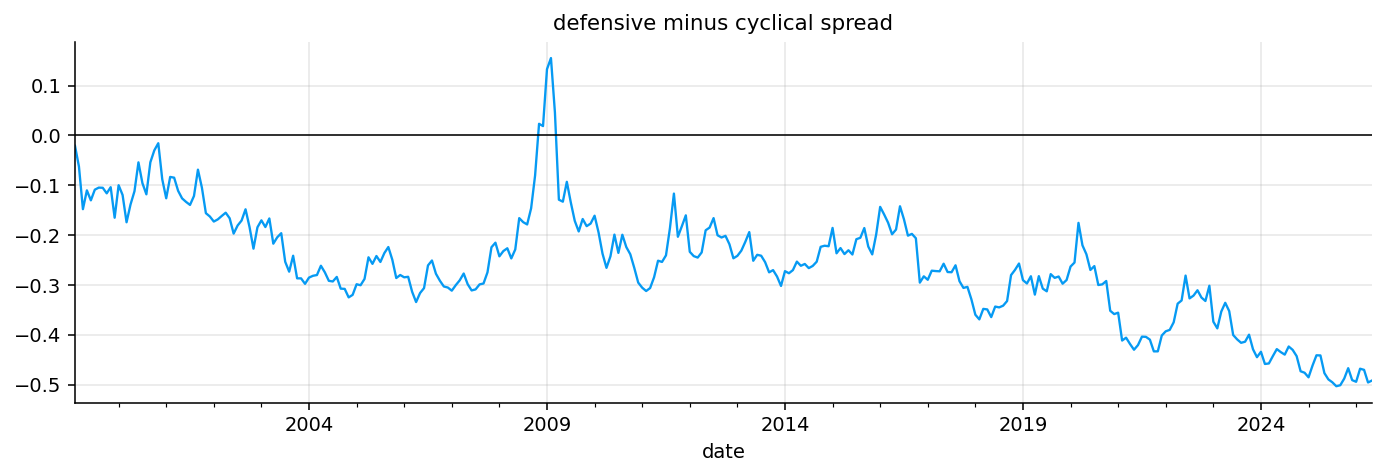

,average_monthly_return
xle,0.0173
xlb,0.0099
dbc,0.0197
gld,0.0151


,average_monthly_return
xlk,NaN
xly,NaN
tlt,NaN


In [33]:
def_cyc_ret = returns[defensive_sector_assets].mean(axis=1) - returns[cyclical_sector_assets].mean(axis=1)
def_cyc_spread = (1.0 + def_cyc_ret.fillna(0.0)).cumprod() - 1.0
ax = def_cyc_spread.plot(figsize=(10, 3.5), lw=1.2)
ax.axhline(0.0, color="black", lw=0.8)
ax.set_title("defensive minus cyclical spread")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
high_inflation_policy = (macro["inflation_pressure_block"] + macro["policy_rate_pressure_block"]).reindex(returns.index) > 1.0
high_policy = macro["policy_rate_pressure_block"].reindex(returns.index) > 1.0
display(returns.loc[high_inflation_policy.fillna(False), inflation_assets].mean().to_frame("average_monthly_return").round(4))
display(returns.loc[high_policy.fillna(False), rate_sensitive_assets].mean().to_frame("average_monthly_return").round(4))


In [34]:
def cross_z(frame):
    mean = frame.mean(axis=1)
    std = frame.std(axis=1, ddof=1).replace(0.0, np.nan)
    return frame.sub(mean, axis=0).div(std, axis=0).fillna(0.0)

def cap_weights(weights, cap=0.40):
    weights = pd.Series(weights, dtype=float).clip(lower=0.0)
    if weights.sum() <= 1e-12:
        return weights
    weights = weights / weights.sum()
    for _ in range(20):
        over = weights > cap
        if not over.any():
            break
        excess = (weights[over] - cap).sum()
        weights[over] = cap
        room = (cap - weights[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        weights.loc[room.index] += excess * room / room.sum()
    return weights / weights.sum()

def momentum_score(ret, assets):
    data = ret[assets]
    mom_12_1 = (1.0 + data.shift(1)).rolling(11).apply(np.prod, raw=True) - 1.0
    ret_6 = (1.0 + data.shift(1)).rolling(6).apply(np.prod, raw=True) - 1.0
    vol_6 = data.shift(1).rolling(6).std(ddof=1) * np.sqrt(12.0)
    return 0.60 * cross_z(mom_12_1) + 0.40 * cross_z(ret_6 / vol_6.replace(0.0, np.nan))


In [35]:
sector_momentum_score = momentum_score(returns, sector_assets)
sector_vol = returns[sector_assets].rolling(6).std(ddof=1) * np.sqrt(12.0)
strategy_end = min(allocation_features.index.max(), returns_raw.index.max())
strategy_dates = allocation_features.index.intersection(returns_raw.index)
strategy_dates = strategy_dates[(strategy_dates >= strategy_start) & (strategy_dates <= strategy_end)]
strategy_returns = returns_raw.loc[strategy_dates.min():strategy_end, strategy_assets]
missing_share = strategy_returns.isna().mean()
display(missing_share.to_frame("missing_share_in_strategy_window"))
strategy_returns = strategy_returns.fillna(0.0)
stress = allocation_features["best_fci_percentile"].reindex(strategy_dates)
slope = allocation_features["best_fci_3m_change"].reindex(strategy_dates).clip(lower=0.0)
risky_weight = pd.Series(1.0, index=stress.index)
risky_weight -= ((stress - 0.60).clip(0.0, 0.25) / 0.25) * 0.35
risky_weight -= (slope.clip(0.0, 0.75) / 0.75) * 0.10
risky_weight = risky_weight.clip(0.50, 1.00).rename("risky_weight")
display(pd.DataFrame({"strategy_start": [strategy_start], "strategy_end": [strategy_end], "strategy_months": [len(strategy_dates)], "latest_month": [strategy_dates.max()], "strategy_fci": [strategy_fci_name], "minimum_risky_weight": [risky_weight.min()]}))


,missing_share_in_strategy_window
cash,0.000000
dbc,0.108209
gld,0.052239
ief,0.000000
shy,0.000000
spy,0.000000
tlt,0.000000
xlb,0.000000
xle,0.000000
xlf,0.000000


,strategy_start,strategy_end,strategy_months,latest_month,strategy_fci,minimum_risky_weight
0,1999-07-31,2026-01-31,268,2026-01-31,fci_pca,0.55


In [36]:
def available_assets_at_date(date, candidates, ret):
    return [asset for asset in candidates if asset in ret.columns and date in ret.index and pd.notna(ret.loc[date, asset])]

def defensive_sleeve(row):
    date = row.name
    inflation_policy = row.get("inflation_pressure_block", 0.0) + row.get("policy_rate_pressure_block", 0.0)
    growth = row.get("growth_recession_block", 0.0)
    inflation = row.get("inflation_pressure_block", 0.0)
    if inflation_policy > 1.0:
        candidates = ["gld", "dbc", "shy", "cash"]
    elif growth > 0.75 and inflation <= 0.75:
        candidates = ["ief", "shy", "gld", "cash"]
    else:
        candidates = ["cash", "shy", "ief"]
    picked = available_assets_at_date(date, [x for x in candidates if x in defensive_assets], returns_raw)
    if not picked:
        picked = ["cash"]
    out = pd.Series(0.0, index=defensive_assets)
    out.loc[picked] = 1.0 / len(picked)
    return out

def macro_fit_scores(features, assets):
    rows = []
    for date, row in features.iterrows():
        score = pd.Series(0.0, index=assets)
        for asset in assets:
            if asset in defensive_sector_assets:
                score.loc[asset] += 0.70 * row["best_fci_percentile"] + 0.45 * row["growth_recession_block"]
            if asset in cyclical_sector_assets:
                score.loc[asset] += 0.80 * (1.0 - row["best_fci_percentile"]) - 0.40 * row["growth_recession_block"] - 0.30 * row["macro_breadth_conflict_block"]
            if asset in inflation_assets:
                score.loc[asset] += 0.55 * row["inflation_pressure_block"] - 0.25 * max(row["growth_recession_block"], 0.0)
            if asset in rate_sensitive_assets:
                score.loc[asset] -= 0.45 * row["policy_rate_pressure_block"]
            if asset == "xlf":
                score.loc[asset] -= 0.35 * max(row["policy_rate_pressure_block"], 0.0) * max(row["growth_recession_block"], 0.0)
        rows.append(score.rename(date))
    return cross_z(pd.concat(rows, axis=1).transpose())


In [37]:
equal_rows = []
momentum_rows = []
gated_rows = []
for date in strategy_dates:
    row_equal = pd.Series(0.0, index=strategy_assets)
    row_equal.loc[sector_assets] = 1.0 / len(sector_assets)
    equal_rows.append(row_equal.rename(date))
    row_mom = pd.Series(0.0, index=strategy_assets)
    picked = sector_momentum_score.loc[date, sector_assets].dropna().sort_values(ascending=0).head(3).index.tolist()
    if picked:
        inv = (1.0 / sector_vol.loc[date, picked].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
        row_mom.loc[inv.index] = cap_weights(inv if len(inv) else pd.Series(1.0, index=picked), 0.40)
    momentum_rows.append(row_mom.rename(date))
    row_gated = row_equal * float(risky_weight.loc[date])
    sleeve = defensive_sleeve(allocation_features.loc[date])
    row_gated.loc[sleeve.index] += (1.0 - float(risky_weight.loc[date])) * sleeve
    gated_rows.append(row_gated.rename(date))
equal_sector_weights = pd.concat(equal_rows, axis=1).transpose().fillna(0.0)
momentum_weights = pd.concat(momentum_rows, axis=1).transpose().fillna(0.0)
gated_weights = pd.concat(gated_rows, axis=1).transpose().fillna(0.0)


In [38]:
macro_fit_score = macro_fit_scores(allocation_features.reindex(strategy_dates), sector_assets)
macro_support_score = cross_z(pd.DataFrame({asset: 0.20 * allocation_features["goldilocks_support"].reindex(strategy_dates) - 0.20 * allocation_features["macro_breadth_conflict_block"].reindex(strategy_dates) + (0.35 * allocation_features["inflation_pressure_block"].reindex(strategy_dates) if asset in inflation_assets else 0.0) for asset in sector_assets}))
recent_risk_penalty = cross_z(sector_vol.reindex(strategy_dates).fillna(0.0)) + cross_z((-returns[sector_assets].rolling(3).sum()).reindex(strategy_dates).clip(lower=0.0).fillna(0.0))
final_sector_score = 0.65 * sector_momentum_score.reindex(strategy_dates) + 0.20 * macro_fit_score + 0.10 * macro_support_score - 0.05 * recent_risk_penalty
fci_momentum_rows = []
selected_sector_rows = []
for date in strategy_dates:
    row = pd.Series(0.0, index=strategy_assets)
    picked = final_sector_score.loc[date, sector_assets].dropna().sort_values(ascending=0).head(3).index.tolist()
    if picked:
        inv = (1.0 / sector_vol.loc[date, picked].replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).dropna()
        row.loc[inv.index] = cap_weights(inv if len(inv) else pd.Series(1.0, index=picked), 0.40) * float(risky_weight.loc[date])
    sleeve = defensive_sleeve(allocation_features.loc[date])
    row.loc[sleeve.index] += (1.0 - float(risky_weight.loc[date])) * sleeve
    fci_momentum_rows.append(row.rename(date))
    selected_sector_rows.append({"date": date, "selected": ", ".join(picked)})
fci_momentum_weights = pd.concat(fci_momentum_rows, axis=1).transpose().fillna(0.0)
selected_sector_table = pd.DataFrame(selected_sector_rows).set_index("date")
display(selected_sector_table.tail(12))


,selected
date,
2025-02-28,"xly, xlf, xlu"
2025-03-31,"xlf, xlu, xly"
2025-04-30,"xlf, xlu, xlp"
2025-05-31,"xlf, xly, xlp"
2025-06-30,"xlf, xlu, xli"
2025-07-31,"xlu, xlf, xli"
2025-08-31,"xlu, xli, xlf"
2025-09-30,"xlf, xly, xli"
2025-10-31,"xly, xlk, xli"


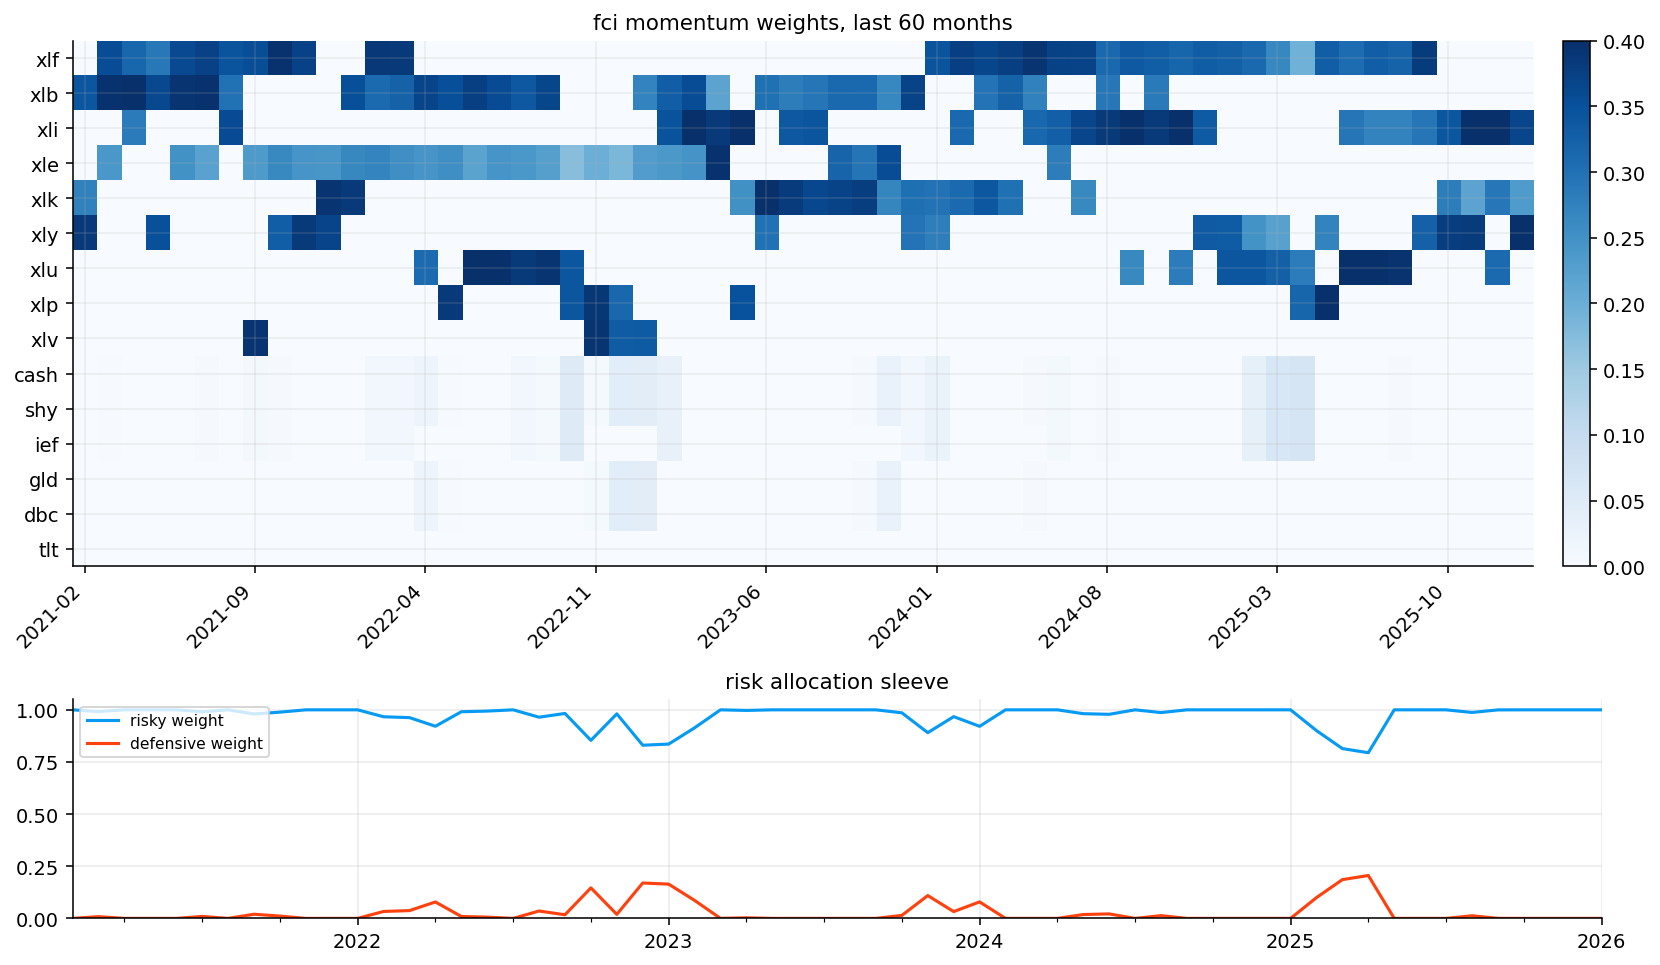

In [39]:
plot_weights = fci_momentum_weights[sector_assets + defensive_assets].tail(60)
plot_weights = plot_weights.loc[:, plot_weights.mean().sort_values(ascending=False).index]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [2.4, 1.0]})
im = axes[0].imshow(plot_weights.T, aspect="auto", cmap="Blues", vmin=0.0, vmax=max(0.40, float(plot_weights.max().max())))
axes[0].set_yticks(range(len(plot_weights.columns)))
axes[0].set_yticklabels(plot_weights.columns)
step = max(1, len(plot_weights.index) // 8)
locs = list(range(0, len(plot_weights.index), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([plot_weights.index[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
axes[0].set_title("fci momentum weights, last 60 months")
fig.colorbar(im, ax=axes[0], fraction=0.025, pad=0.02)
risky_weight.reindex(plot_weights.index).plot(ax=axes[1], lw=1.6, color=colors[0], label="risky weight")
(1.0 - risky_weight).reindex(plot_weights.index).plot(ax=axes[1], lw=1.6, color=colors[1], label="defensive weight")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title("risk allocation sleeve")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [40]:
spy_weights = equal_sector_weights.copy() * 0.0
spy_weights["spy"] = 1.0
weights_by_strategy = {"equal_weight_sectors": equal_sector_weights, "momentum_rotation": momentum_weights, "fci_gated_basket": gated_weights, "fci_momentum_rotation": fci_momentum_weights, "spy_buy_hold": spy_weights}
backtest_results = run_many_weights_backtests(weights_by_strategy, returns=strategy_returns, cost_bps=5.0, weight_timing="next_close")
performance_table = build_metrics_table(backtest_results, rf_daily=rf_monthly, annualization=12.0)
trade_table = build_trade_table(backtest_results)
performance_table.columns = [str(col).lower().replace(" ", "_") for col in performance_table.columns]
trade_table.columns = [str(col).lower().replace(" ", "_") for col in trade_table.columns]
strategy_return_table = pd.concat({name: result.net_returns for name, result in backtest_results.items()}, axis=1).fillna(0.0)
strategy_nav_table = pd.concat({name: result.net_values for name, result in backtest_results.items()}, axis=1)
rolling_12m = (1.0 + strategy_return_table).rolling(12).apply(np.prod, raw=True) - 1.0
performance_table["hit_rate"] = (strategy_return_table > 0).mean()
performance_table["worst_12m_return"] = rolling_12m.min()
performance_table["turnover"] = trade_table["avg_turnover"]
performance_table["cost_drag"] = trade_table["cost_drag"]
display(performance_table.round(4))
full_defensive_first_month = monthly_close[optional_defensive_assets].apply(pd.Series.first_valid_index).max()
full_defensive_start = max(strategy_start, full_defensive_first_month + pd.offsets.MonthEnd(6))
full_defensive_dates = strategy_dates[strategy_dates >= full_defensive_start]
full_defensive_returns = returns_raw.loc[full_defensive_dates.min():strategy_end, strategy_assets]
display(full_defensive_returns.isna().mean().to_frame("missing_share_in_full_defensive_window"))
full_defensive_weights = {name: weights.reindex(full_defensive_dates).dropna(how="all") for name, weights in weights_by_strategy.items()}
full_defensive_results = run_many_weights_backtests(full_defensive_weights, returns=full_defensive_returns.fillna(0.0), cost_bps=5.0, weight_timing="next_close")
full_defensive_performance_table = build_metrics_table(full_defensive_results, rf_daily=rf_monthly, annualization=12.0)
full_defensive_performance_table.columns = [str(col).lower().replace(" ", "_") for col in full_defensive_performance_table.columns]
display(pd.DataFrame({"full_defensive_start": [full_defensive_start], "full_defensive_months": [len(full_defensive_dates)]}))
display(full_defensive_performance_table.round(4))


,cagr,vol,sharpe,max_drawdown,calmar,sortino,hit_rate,worst_12m_return,turnover,cost_drag
Strategy,,,,,,,,,,
equal_weight_sectors,0.1070,0.1433,0.5069,-0.4913,0.2178,0.6570,0.6704,-0.4294,0.0136,0.0006
momentum_rotation,0.1099,0.1384,0.5379,-0.3766,0.2918,0.7544,0.6292,-0.3225,0.2632,0.0124
fci_gated_basket,0.1120,0.1310,0.5752,-0.3425,0.3269,0.8295,0.6704,-0.2741,0.0343,0.0016
fci_momentum_rotation,0.0990,0.1394,0.4620,-0.2553,0.3879,0.6669,0.6367,-0.2132,0.2670,0.0164
spy_buy_hold,0.1086,0.1449,0.5132,-0.5078,0.2139,0.6859,0.6704,-0.4342,0.0019,0.0000


,missing_share_in_full_defensive_window
cash,0.0
dbc,0.0
gld,0.0
ief,0.0
shy,0.0
spy,0.0
tlt,0.0
xlb,0.0
xle,0.0
xlf,0.0


,full_defensive_start,full_defensive_months
0,2006-08-31,234


,cagr,vol,sharpe,max_drawdown,calmar,sortino
Strategy,,,,,,
equal_weight_sectors,0.1038,0.1508,0.4675,-0.4913,0.2112,0.6162
momentum_rotation,0.1065,0.1432,0.5066,-0.3766,0.2829,0.7158
fci_gated_basket,0.1096,0.1375,0.5367,-0.3425,0.3200,0.7864
fci_momentum_rotation,0.0895,0.1427,0.4028,-0.2553,0.3504,0.5799
spy_buy_hold,0.1102,0.1525,0.4985,-0.5078,0.2169,0.6770


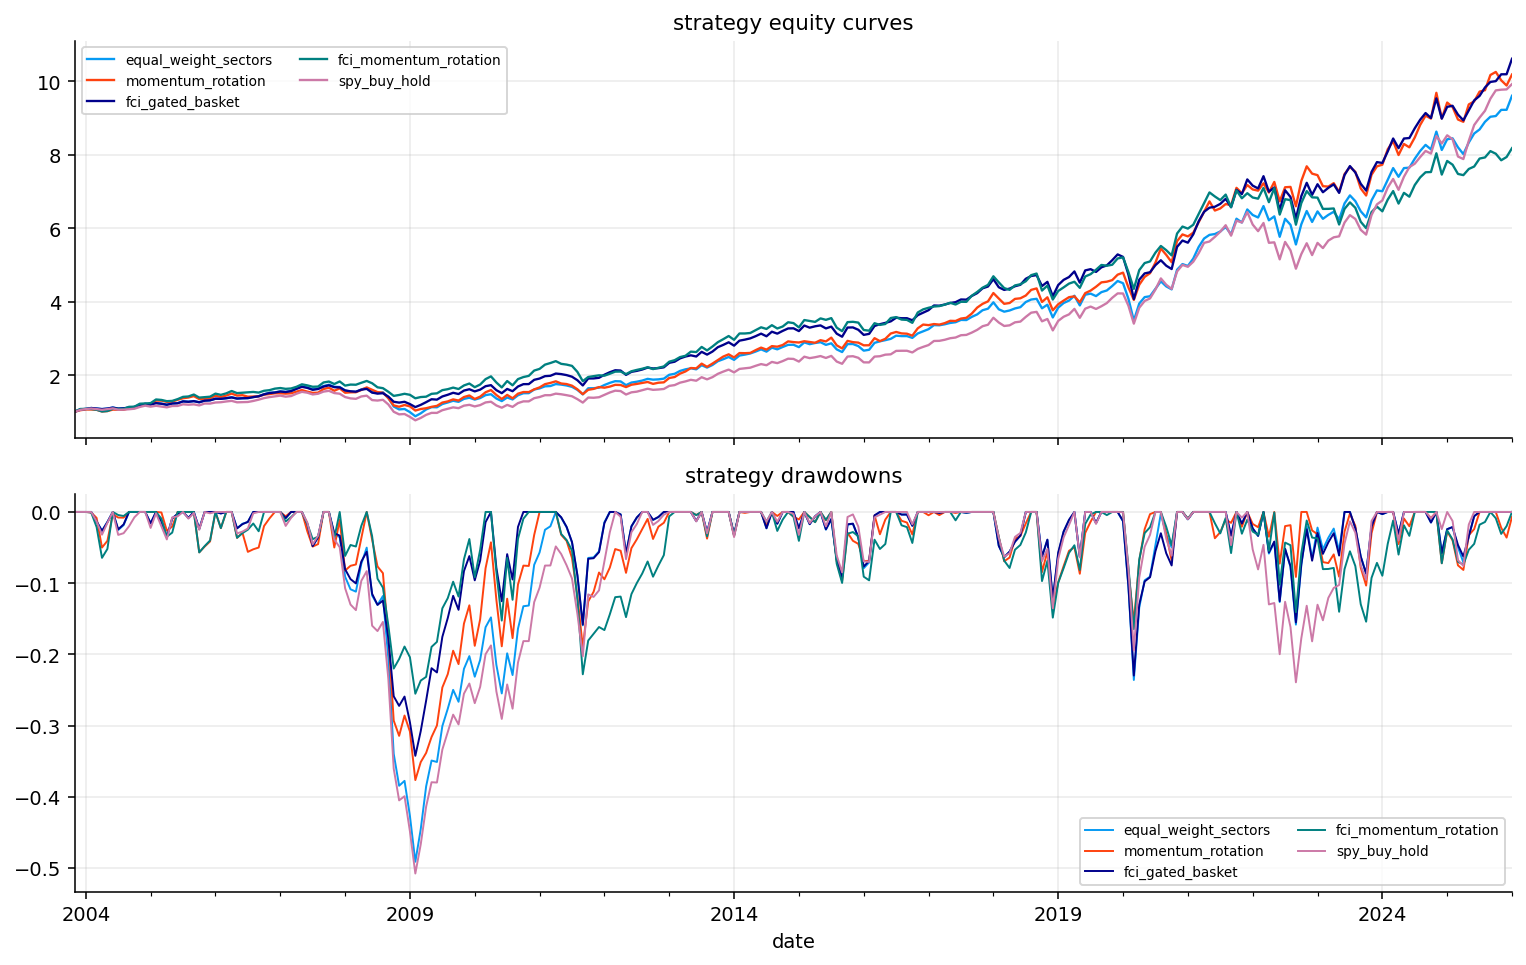

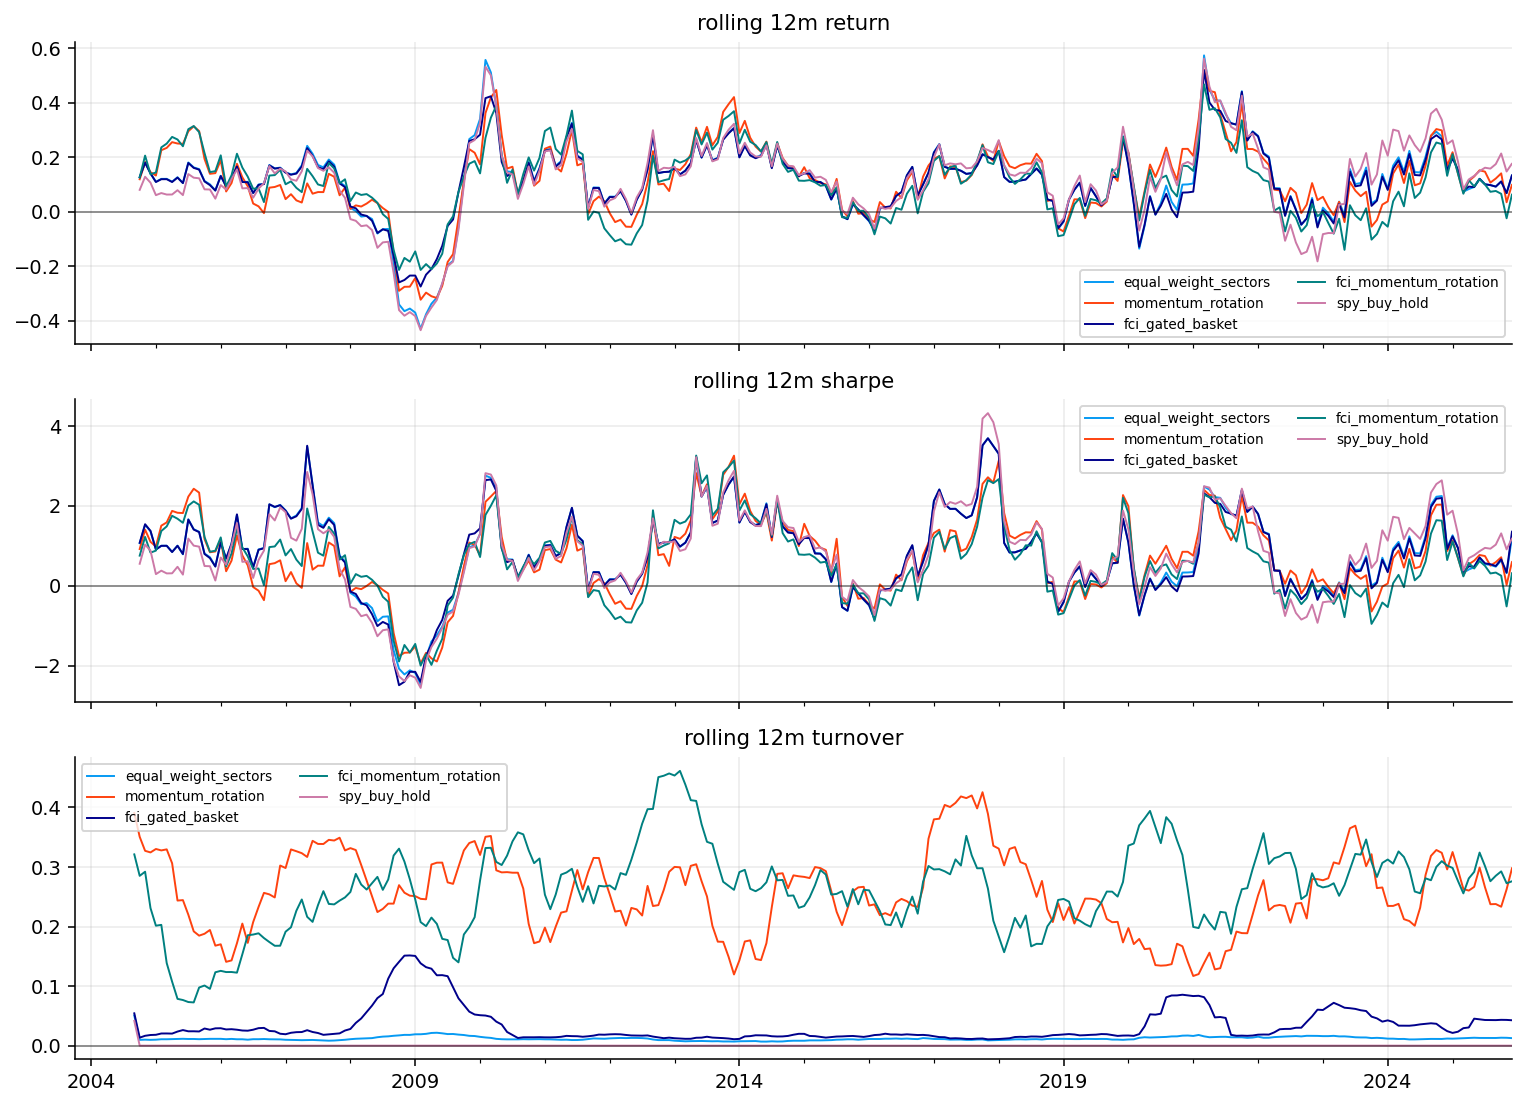

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for j, col in enumerate(strategy_nav_table.columns):
    strategy_nav_table[col].plot(ax=axes[0], lw=1.2, color=colors[j % len(colors)], label=col)
drawdowns = strategy_nav_table.apply(calc_drawdown)
for j, col in enumerate(drawdowns.columns):
    drawdowns[col].plot(ax=axes[1], lw=1.0, color=colors[j % len(colors)], label=col)
axes[0].set_title("strategy equity curves")
axes[1].set_title("strategy drawdowns")
axes[0].legend(ncol=2, fontsize=7)
axes[1].legend(ncol=2, fontsize=7)
for ax in axes:
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for j, col in enumerate(rolling_12m.columns):
    rolling_12m[col].plot(ax=axes[0], lw=1.0, color=colors[j % len(colors)], label=col)
rolling_sharpe = (strategy_return_table - rf_monthly).rolling(12).mean() / strategy_return_table.rolling(12).std() * np.sqrt(12.0)
for j, col in enumerate(rolling_sharpe.columns):
    rolling_sharpe[col].plot(ax=axes[1], lw=1.0, color=colors[j % len(colors)], label=col)
turnover_table = pd.concat({name: result.turnover for name, result in backtest_results.items()}, axis=1)
for j, col in enumerate(turnover_table.columns):
    turnover_table[col].rolling(12).mean().plot(ax=axes[2], lw=1.0, color=colors[j % len(colors)], label=col)
for ax, title in zip(axes, ["rolling 12m return", "rolling 12m sharpe", "rolling 12m turnover"]):
    ax.axhline(0.0, color="black", lw=0.8, alpha=0.5)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()


In [42]:
stress_rows = []
for name, dates in crisis_windows.items():
    ret_window = strategy_return_table.loc[dates[0]:dates[1]]
    if len(ret_window) == 0:
        continue
    for strategy in ret_window.columns:
        stress_rows.append({"window": name, "strategy": strategy, "return": float((1.0 + ret_window[strategy]).prod() - 1.0), "max_drawdown": float(drawdown_series(ret_window[strategy], input_kind="returns").min())})
stress_window_table = pd.DataFrame(stress_rows).set_index(["window", "strategy"])
display(stress_window_table.round(4))


return  max_drawdown
window               strategy                                   
financial_crisis     equal_weight_sectors  -0.3713       -0.3599
                     momentum_rotation     -0.2903       -0.2449
                     fci_gated_basket      -0.2094       -0.2009
                     fci_momentum_rotation -0.1460       -0.1144
                     spy_buy_hold          -0.3695       -0.3574
covid_crash          equal_weight_sectors  -0.1227       -0.1455
                     momentum_rotation     -0.0686       -0.0774
                     fci_gated_basket      -0.1188       -0.1402
                     fci_momentum_rotation -0.0669       -0.0949
                     spy_buy_hold          -0.0918       -0.1249
inflation_rate_shock equal_weight_sectors  -0.0619       -0.1583
                     momentum_rotation      0.0152       -0.0912
                     fci_gated_basket      -0.0621       -0.1552
                     fci_momentum_rotation -0.0387       -0.1408
                     spy_buy_hold          -0.1774       -0.2025

In [43]:
latest_date = fci_momentum_weights.index.max()
latest_features = allocation_features.loc[latest_date]
decision_rows = []
for asset in sector_assets + defensive_assets:
    momentum_value = sector_momentum_score.get(asset, pd.Series(0.0, index=strategy_dates)).reindex(strategy_dates).loc[latest_date] if asset in sector_assets else 0.0
    fit_value = macro_fit_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    support_value = macro_support_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    penalty_value = recent_risk_penalty.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    final_value = final_sector_score.get(asset, pd.Series(0.0, index=strategy_dates)).loc[latest_date] if asset in sector_assets else 0.0
    weight_value = fci_momentum_weights.loc[latest_date, asset] if asset in fci_momentum_weights.columns else 0.0
    if asset in inflation_assets and latest_features["inflation_pressure_block"] > 0.75 and weight_value > 0:
        reason = "inflation hedge"
    elif asset in defensive_assets and latest_features["best_fci_percentile"] > 0.65 and weight_value > 0:
        reason = "defensive stress protection"
    elif asset in rate_sensitive_assets and latest_features["policy_rate_pressure_block"] > 0.75 and fit_value < 0:
        reason = "rate-pressure penalty"
    elif asset in cyclical_sector_assets and latest_features["best_fci_percentile"] < 0.45 and weight_value > 0:
        reason = "risk-on cyclical"
    elif momentum_value < 0 and weight_value <= 1e-8:
        reason = "weak momentum"
    else:
        reason = "macro stress exclusion" if weight_value <= 1e-8 else "risk-on cyclical"
    decision_rows.append({"date": latest_date, "selected fci model": strategy_fci_name, "selected fci value": latest_features["best_fci_value"], "selected fci percentile": latest_features["best_fci_percentile"], "selected fci 3m change": latest_features["best_fci_3m_change"], "dominant macro block": latest_features["dominant_macro_block"], "sector": asset, "momentum_score": momentum_value, "macro_fit_score": fit_value, "macro_support_score": support_value, "recent_risk_penalty": penalty_value, "final_score": final_value, "portfolio_weight": weight_value, "short reason category": reason})
latest_decision_board = pd.DataFrame(decision_rows).sort_values("portfolio_weight", ascending=0)
display(latest_decision_board.round(4))


,date,selected fci model,selected fci value,selected fci percentile,selected fci 3m change,dominant macro block,sector,momentum_score,macro_fit_score,macro_support_score,recent_risk_penalty,final_score,portfolio_weight,short reason category
8,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xly,0.0403,1.0952,-0.5040,-1.7777,0.2837,0.4000,risk-on cyclical
3,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xli,0.7609,0.6635,-0.5040,-1.4127,0.6475,0.3667,risk-on cyclical
4,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlk,1.4418,-1.2853,-0.5040,3.0926,0.4751,0.2333,risk-on cyclical
2,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlf,-0.1387,0.6635,-0.5040,-1.4445,0.0644,0.0000,weak momentum
1,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xle,-0.0821,-0.8236,1.7638,1.1999,-0.1017,0.0000,weak momentum
5,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlp,-1.4599,-0.6234,-0.5040,-0.2562,-1.1112,0.0000,weak momentum
0,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlb,-0.7140,1.5569,1.7638,0.4703,0.0002,0.0000,weak momentum
6,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlu,0.0864,-0.6234,-0.5040,0.5112,-0.1445,0.0000,macro stress exclusion
7,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,xlv,0.0653,-0.6234,-0.5040,-0.3828,-0.1135,0.0000,macro stress exclusion
9,2026-01-31,fci_pca,-0.3627,0.422,-0.0043,labor_cooling_block,cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,macro stress exclusion


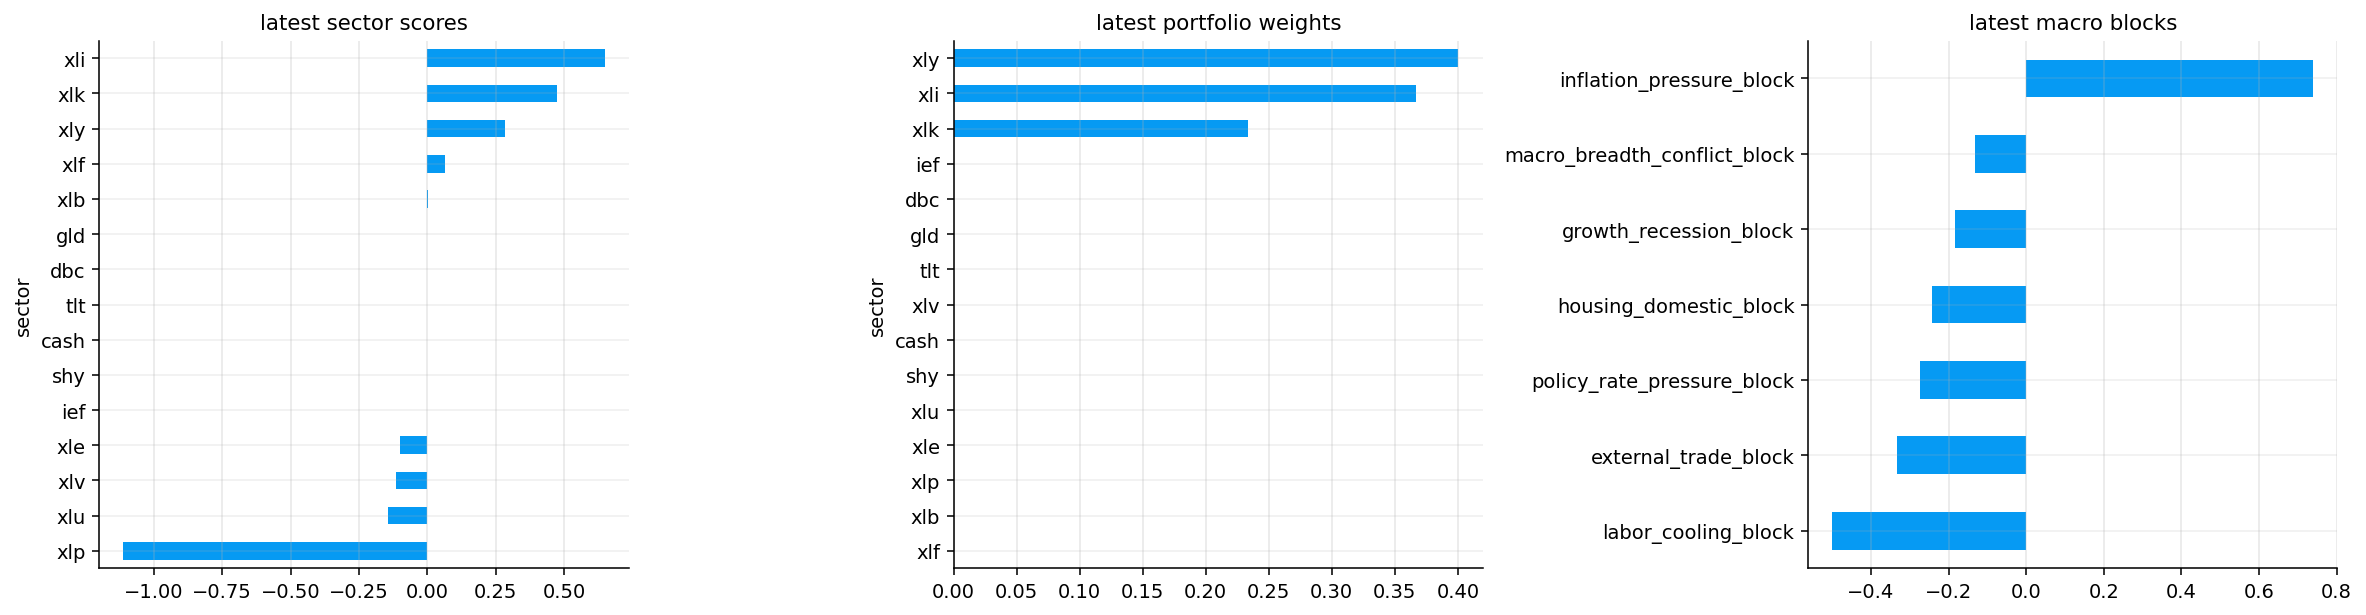

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
latest_decision_board.set_index("sector")["final_score"].sort_values().plot(kind="barh", ax=axes[0])
latest_decision_board.set_index("sector")["portfolio_weight"].sort_values().plot(kind="barh", ax=axes[1])
macro.loc[latest_date, block_cols].sort_values().plot(kind="barh", ax=axes[2])
for ax, title in zip(axes, ["latest sector scores", "latest portfolio weights", "latest macro blocks"]):
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


,missing_share_in_strategy_window
CGL-C.TO,0.0
XBB.TO,0.0
XEG.TO,0.0
XFN.TO,0.0
XIC.TO,0.0
XIT.TO,0.0
XLB.TO,0.0
XMA.TO,0.0
XRE.TO,0.0
XSB.TO,0.0


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,final_score
model,,,,,,,,,
fci_blend,168,2012-02-29,2026-01-31,0.2353,0.0121,0.6,0.0488,0.5223,0.7125
fci_prob,134,2014-12-31,2026-01-31,0.2506,0.0150,0.3,0.0379,0.5354,0.6500
fci_pls,179,2011-03-31,2026-01-31,0.1687,0.0115,0.4,0.0186,0.8002,0.4250
fci_pca,328,1998-10-31,2026-01-31,0.0645,0.0076,1.0,0.0428,0.6052,0.3625
fci_econ,375,1994-11-30,2026-01-31,0.1234,0.0088,0.5,0.0376,0.6337,0.3500


,observations,first_valid_date,last_valid_date,future_stress_rank_ic,drawdown_spread,monotonicity_score,volatility_spread,stability_score,final_score
model,,,,,,,,,
fci_pls,58,2021-04-30,2026-01-31,0.5278,0.0248,1.0,0.0715,0.8405,0.9000
fci_prob,58,2021-04-30,2026-01-31,0.4713,0.0301,0.7,0.0996,0.6294,0.7750
fci_blend,58,2021-04-30,2026-01-31,0.1970,0.0094,0.4,0.0339,0.6582,0.4625
fci_econ,58,2021-04-30,2026-01-31,0.0799,0.0038,0.3,0.0419,0.6367,0.2875
fci_pca,58,2021-04-30,2026-01-31,-0.2285,-0.0191,-0.3,-0.0155,0.7426,0.0750


,full_sample_score_winner,test_sample_score_winner,selected_strategy_fci,selection_rule
0,fci_blend,fci_pls,fci_blend,Best history-eligible FCI selected from the fu...


,strategy_start,strategy_end,strategy_fci,test_start
0,2012-07-31,2026-01-31,fci_blend,2021-04-30


,cagr,vol,sharpe,max_drawdown,calmar,sortino,turnover
Strategy,,,,,,,
equal_weight_sectors,0.1324,0.1297,0.6794,-0.2288,0.5789,0.7794,0.0204
momentum_rotation,0.1340,0.1311,0.6985,-0.1961,0.6834,0.8124,0.2034
fci_gated_basket,0.1166,0.1155,0.6253,-0.2235,0.5219,0.6813,0.1107
fci_momentum_rotation,0.1309,0.1161,0.7490,-0.1912,0.6848,0.8516,0.2187
xic_buy_hold,0.1279,0.1279,0.6612,-0.2248,0.5691,0.7522,0.0042


,date,selected fci model,selected fci value,selected fci percentile,selected fci 3m change,dominant macro block,sector,momentum_score,macro_fit_score,macro_support_score,recent_risk_penalty,final_score,portfolio_weight,short reason category
0,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XFN.TO,0.9797,0.3697,-0.5855,-1.5112,0.7278,0.3967,risk-on cyclical
1,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XEG.TO,-0.2198,0.9201,1.4639,0.6933,0.1529,0.3272,risk-on cyclical
2,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XMA.TO,1.3883,0.9201,1.4639,-0.1263,1.2391,0.2679,risk-on cyclical
8,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XBB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0041,risk-on cyclical
7,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XSB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0041,risk-on cyclical
3,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XRE.TO,-0.6542,0.2391,-0.5855,-1.7426,-0.3488,0.0000,weak momentum
4,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XUT.TO,-0.4619,-1.4093,-0.5855,-0.6682,-0.6072,0.0000,weak momentum
6,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XIT.TO,-0.6786,0.3709,-0.5855,2.7555,-0.5633,0.0000,weak momentum
5,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XST.TO,-0.3535,-1.4105,-0.5855,0.5995,-0.6004,0.0000,weak momentum
9,2026-01-31,fci_blend,-0.6483,0.3353,0.0614,external_trade_block,XLB.TO,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,macro stress exclusion


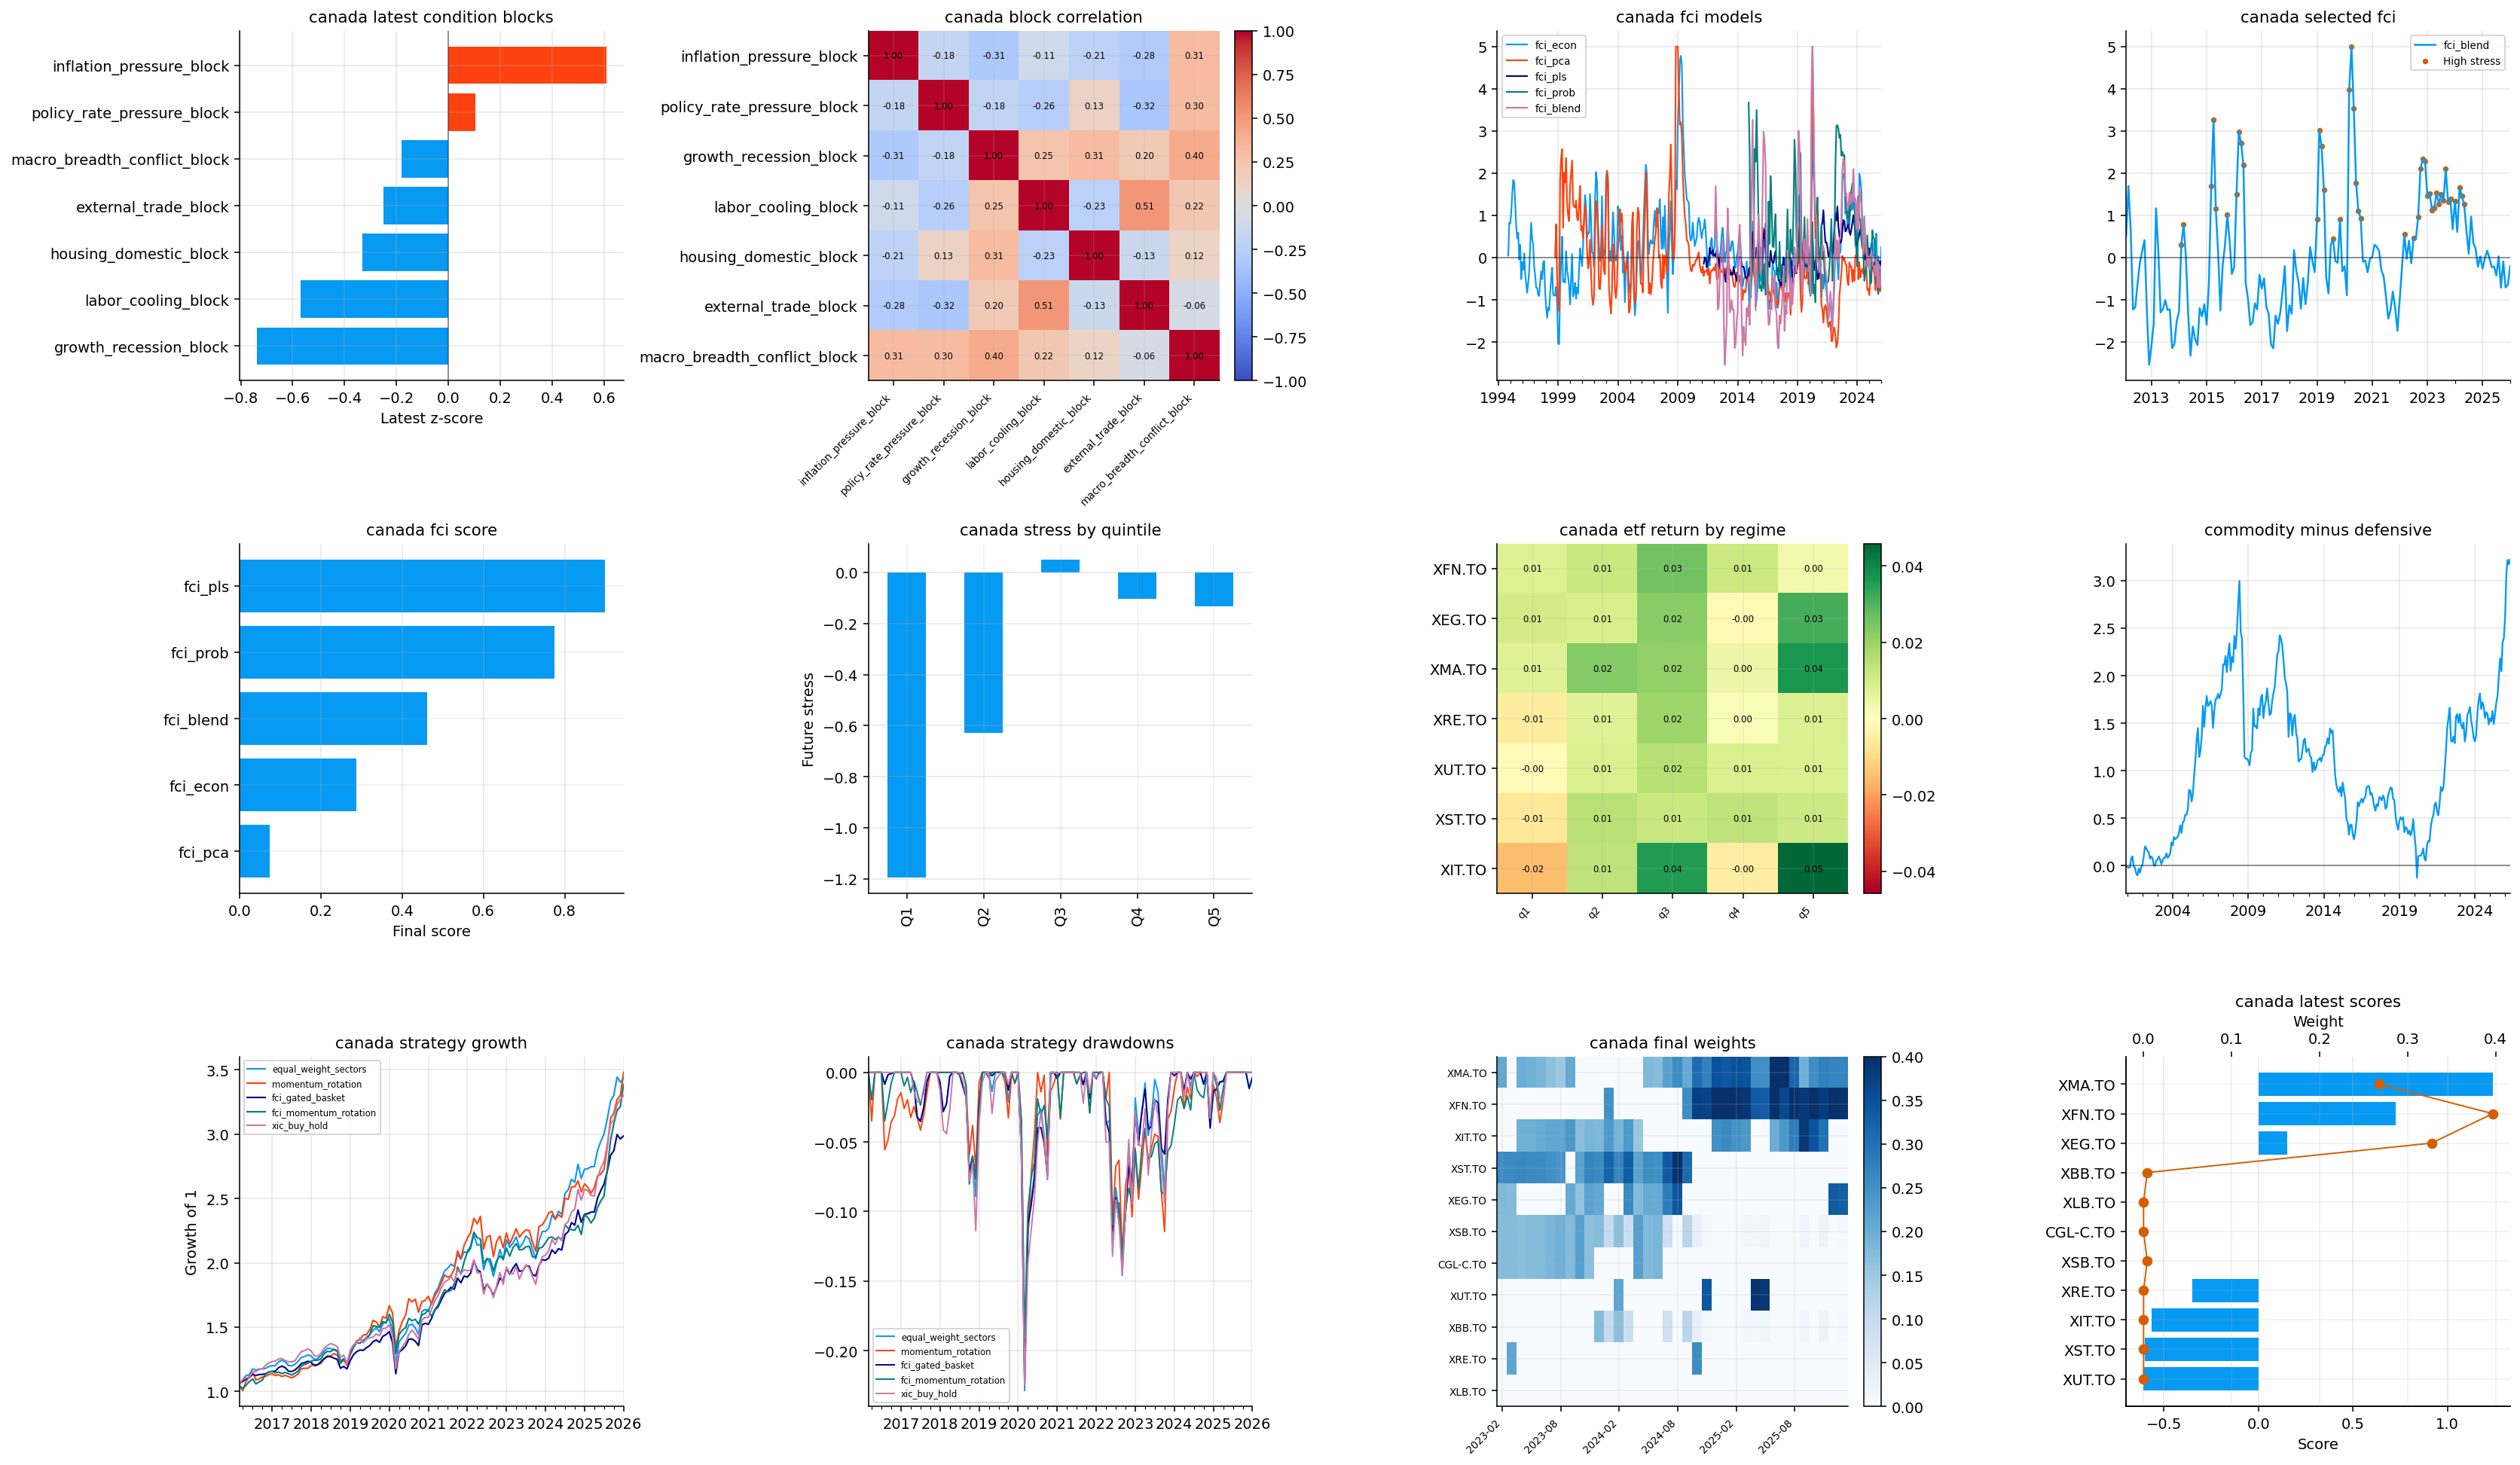

In [45]:
from quantfinlab.dataio import load_macro_factors, load_yfinance_panel
from quantfinlab.portfolio import prices_to_returns
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_metrics_table, build_trade_table
from quantfinlab.macro.indicators import inflation_level_pressure, inflation_impulse, inflation_acceleration, inflation_diffusion, policy_tightness, policy_shock, real_rate_squeeze, policy_catchup_risk, growth_momentum_stress, growth_acceleration_stress, growth_breadth_stress, survey_warning, labor_cooling, sahm_pressure, housing_impulse_stress, housing_rate_squeeze, external_demand_stress, external_vulnerability, stress_breadth, severe_stress_breadth, stagflation_pressure, goldilocks_support, inflation_pressure_block, policy_rate_pressure_block, growth_recession_block, labor_cooling_block, housing_domestic_block, external_trade_block, macro_breadth_conflict_block
from quantfinlab.macro.models import economic_fci, pca_fci, targeted_pls_fci, stress_probability_fci, blended_fci, fci_percentile, fci_change, future_stress_target, fci_quintile_report, fci_model_scores
from quantfinlab.macro.allocation import equal_sector_weights, momentum_sector_weights, fci_gated_weights, fci_momentum_weights, latest_decision_table
from quantfinlab.plotting.macro import plot_macro_blocks, plot_block_correlation, plot_fci_models, plot_fci_vs_nfci, plot_fci_model_scores, plot_fci_quintile_stress, plot_sector_regime_heatmap, plot_defensive_cyclical_spread, plot_strategy_growth, plot_strategy_drawdowns, plot_strategy_weights, plot_latest_scores

factors = load_macro_factors(data_dir / "ca_macro_factors.csv")
min_history = 48
inflation = pd.concat([
    inflation_level_pressure(factors, min_history=min_history),
    inflation_impulse(factors, min_history=min_history),
    inflation_acceleration(factors, min_history=min_history),
    inflation_diffusion(factors, min_history=min_history),
], axis=1)
policy = pd.concat([
    policy_tightness(factors, min_history=min_history),
    policy_shock(factors, min_history=min_history),
], axis=1)
policy["real_rate_squeeze"] = real_rate_squeeze(policy["policy_tightness"], inflation["inflation_impulse"], min_history=min_history)
policy["policy_catchup_risk"] = policy_catchup_risk(inflation["inflation_level_pressure"], policy["policy_tightness"], min_history=min_history)
growth = pd.concat([
    growth_momentum_stress(factors, min_history=min_history),
    growth_acceleration_stress(factors, min_history=min_history),
    growth_breadth_stress(factors, min_history=min_history),
    survey_warning(factors, min_history=min_history),
], axis=1)
labor = pd.concat([
    labor_cooling(factors, min_history=min_history),
    sahm_pressure(factors, min_history=min_history),
], axis=1)
housing = pd.concat([
    housing_impulse_stress(factors, min_history=min_history),
], axis=1)
housing["housing_rate_squeeze"] = housing_rate_squeeze(housing["housing_impulse_stress"], policy["policy_tightness"])
external = pd.concat([
    external_demand_stress(factors, min_history=min_history),
    external_vulnerability(factors, min_history=min_history),
], axis=1)
signals = pd.concat([inflation, policy, growth, labor, housing, external], axis=1)
breadth = pd.concat([
    stress_breadth(signals, min_history=min_history),
    severe_stress_breadth(signals, min_history=min_history),
    stagflation_pressure(signals),
    goldilocks_support(signals),
], axis=1)
signals = pd.concat([signals, breadth], axis=1)
blocks = pd.concat([
    inflation_pressure_block(signals),
    policy_rate_pressure_block(signals),
    growth_recession_block(signals),
    labor_cooling_block(signals),
    housing_domestic_block(signals),
    external_trade_block(signals),
    macro_breadth_conflict_block(signals),
], axis=1)
macro = pd.concat([signals, blocks], axis=1)
macro["n_blocks_available"] = blocks.notna().sum(axis=1)
macro = macro.loc[macro["n_blocks_available"] >= 5]
blocks = macro[blocks.columns]
risky_assets = ["XFN.TO", "XEG.TO", "XMA.TO", "XRE.TO", "XUT.TO", "XST.TO", "XIT.TO"]
defensive_assets = ["XSB.TO", "XBB.TO", "XLB.TO", "CGL-C.TO"]
signal_assets = ["FXC", "UUP", "HYG", "LQD", "SPY"]
tickers = ["XIC.TO", "XIU.TO"] + risky_assets + defensive_assets + signal_assets
prices = load_yfinance_panel(etf_path, fields=("close",), tickers=tickers, lowercase=False)["close"].ffill(limit=3)
monthly_prices = prices.groupby(prices.index.to_period("M")).last()
monthly_prices.index = monthly_prices.index.to_timestamp("M")
returns_raw = prices_to_returns(monthly_prices, kind="simple")
returns = returns_raw.copy()
target = future_stress_target(returns_raw, asset="XIC.TO", min_history=min_history).reindex(macro.index.union(returns_raw.index)).sort_index()
fci_econ = economic_fci(blocks, min_history=min_history).rename("fci_econ")
fci_pca = pca_fci(blocks, min_history=min_history, min_blocks=5).rename("fci_pca")
fci_pls = targeted_pls_fci(blocks, target["future_stress"], min_history=min_history, n_components=1, min_blocks=5, embargo_months=3).rename("fci_pls")
prob = stress_probability_fci(pd.concat([blocks, fci_econ, fci_pca, fci_pls], axis=1), target["future_stress"], min_history=min_history, embargo_months=3).rename(columns=str.lower)
fci_blend = blended_fci(fci_pls, fci_pca, fci_econ, min_history=12).rename("fci_blend")
fci_models = pd.concat([fci_econ, fci_pca, fci_pls, prob["fci_prob_z"].rename("fci_prob"), fci_blend], axis=1).reindex(macro.index)
full_scoreboard = fci_model_scores(fci_models, target)
all_assets = sorted(set(risky_assets + defensive_assets + ["XIC.TO"]))
first_month = monthly_prices[all_assets].apply(pd.Series.first_valid_index)
start_date = max(macro.index.min(), first_month.max() + pd.offsets.MonthEnd(6))
score_dates = fci_models.index.intersection(returns_raw.index)
score_dates = score_dates[score_dates >= start_date]
split_date = score_dates[int(len(score_dates) * 0.65)] if len(score_dates) else pd.NaT
test_dates = score_dates[score_dates >= split_date]
scoreboard = fci_model_scores(fci_models.reindex(test_dates), target.reindex(test_dates))
history_eligible = full_scoreboard[(full_scoreboard["observations"] >= 120) & (full_scoreboard["first_valid_date"] <= pd.Timestamp("2013-12-31"))]
best_name = history_eligible.index[0] if len(history_eligible) else "fci_pca"
canada_model_choice_table = pd.DataFrame({"full_sample_score_winner": [full_scoreboard.index[0]], "test_sample_score_winner": [scoreboard.index[0]], "selected_strategy_fci": [best_name], "selection_rule": ["Best history-eligible FCI selected from the full-sample scoreboard with at least 120 observations and first valid date no later than 2013-12-31."]})
best_fci = fci_models[best_name].rename(best_name)
best_pct = fci_percentile(best_fci, min_history=min_history).rename("best_fci_percentile")
best_change = fci_change(best_fci, periods=3).rename("best_fci_3m_change")
tradable_macro = macro.shift(1)
features = tradable_macro[["inflation_pressure_block", "policy_rate_pressure_block", "growth_recession_block", "macro_breadth_conflict_block", "goldilocks_support"]].copy()
features["best_fci_percentile"] = best_pct.shift(1)
features["best_fci_3m_change"] = best_change.shift(1)
features["best_fci_value"] = best_fci.shift(1)
dominant_block_values = tradable_macro[blocks.columns].abs()
dominant_macro_block = pd.Series(np.nan, index=dominant_block_values.index, dtype=object)
has_dominant_block = dominant_block_values.notna().any(axis=1)
dominant_macro_block.loc[has_dominant_block] = dominant_block_values.loc[has_dominant_block].idxmax(axis=1)
features["dominant_macro_block"] = dominant_macro_block
features = features.dropna(subset=["best_fci_percentile", "best_fci_3m_change"])
strategy_end = min(features.index.max(), returns_raw.index.max())
dates = features.index.intersection(returns_raw.index)
dates = dates[(dates >= start_date) & (dates <= strategy_end)]
equal_weight = equal_sector_weights(dates, risky_assets, all_assets)
momentum_weight = momentum_sector_weights(returns, risky_assets).reindex(dates).reindex(columns=all_assets).fillna(0.0)
gated_weight, gated_details = fci_gated_weights(features.reindex(dates), risky_assets, defensive_assets, return_details=True)
fci_momentum_weight, details = fci_momentum_weights(returns, features.reindex(dates), risky_assets, defensive_assets, return_details=True)
benchmark_weight = equal_weight.copy() * 0.0
benchmark_weight["XIC.TO"] = 1.0
weights_by_strategy = {"equal_weight_sectors": equal_weight, "momentum_rotation": momentum_weight, "fci_gated_basket": gated_weight, "fci_momentum_rotation": fci_momentum_weight, "xic_buy_hold": benchmark_weight}
strategy_returns = returns_raw.loc[dates.min():strategy_end, all_assets]
missing_share = strategy_returns.isna().mean()
display(missing_share.to_frame("missing_share_in_strategy_window"))
strategy_returns = strategy_returns.fillna(0.0)
results = run_many_weights_backtests(weights_by_strategy, returns=strategy_returns, cost_bps=5.0, weight_timing="next_close")
performance = build_metrics_table(results, rf_daily=rf_monthly, annualization=12.0)
trades = build_trade_table(results)
performance.columns = [str(col).lower().replace(" ", "_") for col in performance.columns]
trades.columns = [str(col).lower().replace(" ", "_") for col in trades.columns]
performance["turnover"] = trades["avg_turnover"]
nav = pd.concat({name: result.net_values for name, result in results.items()}, axis=1)
quintile_report = fci_quintile_report(best_fci, target)
regime_data = pd.concat([best_pct.rename("fci_percentile"), returns[risky_assets].shift(-1)], axis=1).dropna(subset=["fci_percentile"])
regime_data["fci_quintile"] = pd.qcut(regime_data["fci_percentile"].rank(method="first"), 5, labels=["q1", "q2", "q3", "q4", "q5"])
regime_heatmap = regime_data.groupby("fci_quintile", observed=False)[risky_assets].mean()
spread = (1.0 + returns[["XEG.TO", "XMA.TO"]].mean(axis=1).sub(returns[defensive_assets].mean(axis=1), fill_value=0.0)).cumprod() - 1.0
decision = latest_decision_table(features.reindex(dates), fci_momentum_weight, details, selected_fci_model=best_name)
display(full_scoreboard.round(4))
display(scoreboard.round(4))
display(canada_model_choice_table)
display(pd.DataFrame({"strategy_start": [start_date], "strategy_end": [strategy_end], "strategy_fci": [best_name], "test_start": [split_date]}))
display(performance.round(4))
display(decision.round(4))
fig, axes = plt.subplots(3, 4, figsize=(24, 14))
ax = axes.ravel()
plot_macro_blocks(macro, ax=ax[0], title="canada latest condition blocks")
plot_block_correlation(macro, ax=ax[1], title="canada block correlation")
plot_fci_models(fci_models, ax=ax[2], title="canada fci models")
plot_fci_vs_nfci(best_fci, ax=ax[3], title="canada selected fci")
plot_fci_model_scores(scoreboard, ax=ax[4], title="canada fci score")
plot_fci_quintile_stress(quintile_report, ax=ax[5], title="canada stress by quintile")
plot_sector_regime_heatmap(regime_heatmap.transpose(), ax=ax[6], title="canada etf return by regime")
plot_defensive_cyclical_spread(spread, ax=ax[7], title="commodity minus defensive")
plot_strategy_growth(nav, ax=ax[8], title="canada strategy growth")
plot_strategy_drawdowns(nav, ax=ax[9], title="canada strategy drawdowns")
plot_strategy_weights(fci_momentum_weight, ax=ax[10], title="canada final weights")
plot_latest_scores(decision, ax=ax[11], title="canada latest scores")
plt.tight_layout()
plt.show()
